# Agentic Systems - Autonomous Agents

Welcome back, Sacha! You've built a solid foundation across LLM fundamentals, evaluation, and tool use — now it's time to put it all together in something genuinely powerful.

Right now, your LLM applications are still **orchestrated by you** — you decide the sequence of steps, which tools to call, when to stop. **Agentic systems** change that: they give your applications the ability to **reason, plan, and act autonomously**, deciding their own next steps until a task is complete.

That directly unlocks what you're building toward — a SQL agent that doesn't just answer one question, but can **navigate a financial dataset**, chain tool calls intelligently, and recover when something goes wrong. This course gives you the framework to build exactly that, reliably and at production quality. Let's get started!

With your context set, let's jump into the heart of this course: **AI Agents**.

You've already built LLM applications that call tools — but there's a meaningful leap between an app that calls a tool when told to and one that **decides for itself** what to do next, chains multiple actions together, and knows when it's done. That leap is what separates a chatbot from an agent.

In this lesson, we'll unpack exactly what makes a system agentic, how agents are structured and how they operate — and then build one from scratch using **LangGraph**. Let's dive in!

The term **"AI agent"** has gone from niche jargon to one of the hottest phrases in the industry — and the search trend here tells that story clearly. Interest was relatively flat through early 2024, then accelerated sharply, hitting peak search volume by mid-2025.

This isn't just hype cycles — it reflects a genuine shift in what people are building. The community realized that LLMs paired with tools and autonomy can tackle a much broader class of problems than simple question-answering.

Given your work in financial markets — what comes to mind when you hear **"AI agent"**?

To sharpen it a bit further: we call these systems **AI agents** — software that uses AI to pursue goals and complete tasks on behalf of users. The contrast is with **chatbots**, which primarily answer questions from their knowledge base but don't take actions to accomplish anything in the world.

Think about your SQL agent idea. A chatbot might answer _"what's the best model for predicting mortgage prepayment?"_ from training data. An agent would actually **query your financial database**, pull the relevant features, cross-reference results, and return a grounded answer — acting until the task is complete.

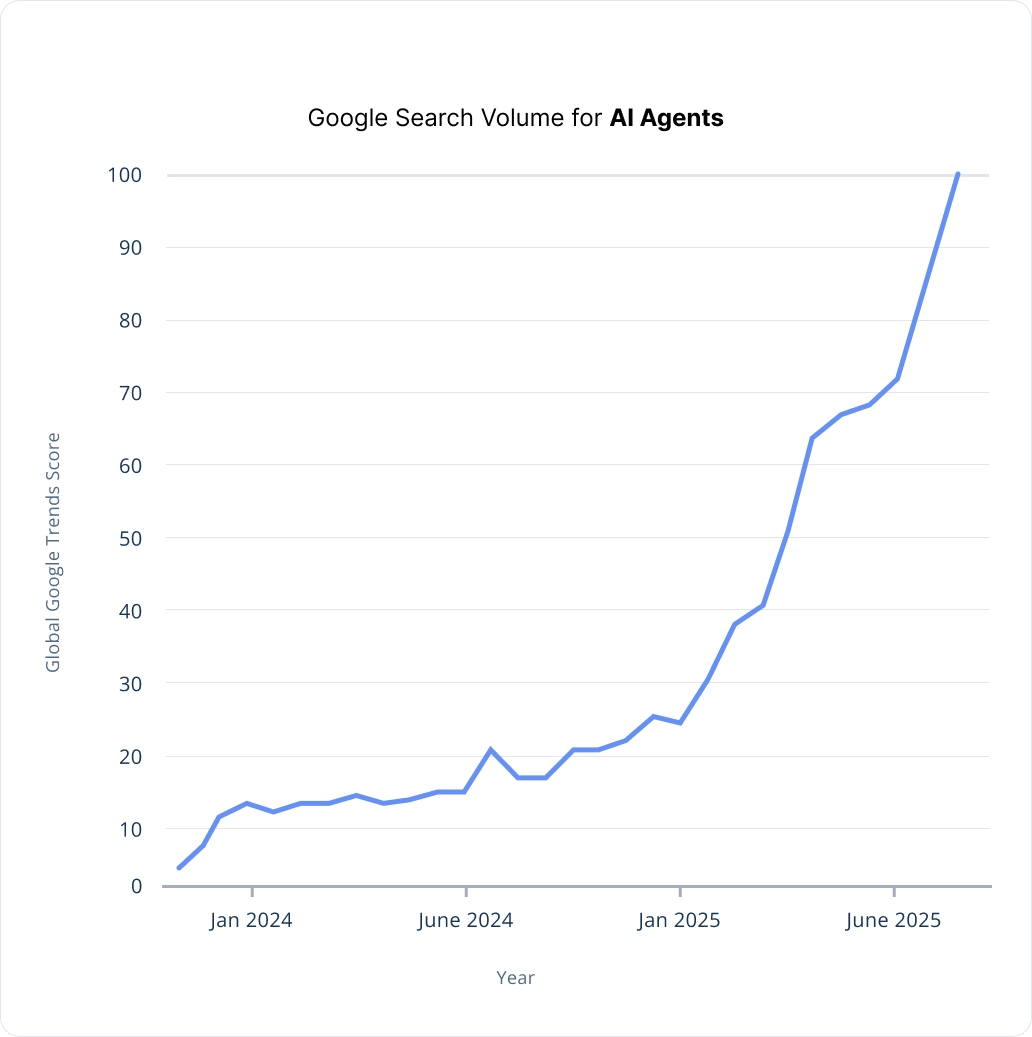

Here's a short demo of **OpenAI's ChatGPT Agent** — under 2 minutes. Watch how it autonomously researches San Francisco budget data across multiple PDFs, extracts hundreds of numbers, and generates a formatted Excel spreadsheet — all from a single prompt.

Pay attention to how it **plans, executes multiple steps, and completes a complex workflow** without being told exactly what to do at each step. That's the agent vs chatbot distinction in action.

Now that you've seen an agent in action, let's build a precise understanding of what makes a system agentic. It helps to think about agents from **three angles**: their **key characteristics**, their **components**, and how they **operate**. Together these give you a complete mental model — and you'll see all three reflected in everything we build. Let's go!

What makes a system agentic? Three defining characteristics:

- **Goal-orientation**: The system is designed to achieve specific objectives — it's task-driven, not just response-driven
- **Autonomy**: It operates independently, making decisions without constant human input
- **Environmental interaction**: It can both perceive its environment (gathering information) and affect it (taking actions)

These aren't abstract — you've already built something that exhibits all three. The Hotel Assistant from the Tool Use course focused on travel-related tasks, independently decided which tools to call, and both gathered information (searching hotels, checking weather) and affected the environment (making bookings).

Would you say your SQL agent idea shares these same characteristics?

Now let's look at what an agent is actually made of. Every agent has four core components:

- **LLM**: The reasoning engine — understands requests and decides what to do next
- **Tools**: Functions that let the agent perceive and act in its environment
- **Memory**: Conversation history and context that inform future decisions
- **Execution Control**: The mechanism that keeps the loop going — or knows when to stop

Your Hotel Assistant from the Tool Use course had all four: an LLM for thinking, tools for searching hotels and making bookings, conversation history as memory, and a while loop that iterated until no more tool calls were needed.

Your SQL agent would follow the same pattern — with tools like list_tables, get_schema, and execute_query in place of the hotel tools.

But before we touch code, one last piece of the conceptual puzzle — **how agents actually operate**. This will make the code click immediately when we get there.

Agents follow a cycle called **ReAct** (Reasoning and Acting):

- Input: Receive the user's task
- Reason: Analyze the situation — what tools are needed?
- Act: Execute those tools
- Observe: Process the results
- Reason again: Are we done, or do we need more actions?
- Repeat until the task is complete

You can see this cycle here — the Reason and Act nodes loop back on each other, with the LLM, Memory, and Tools feeding into that cycle. The loop exits only when the LLM decides the task is done.

This is exactly what your Hotel Assistant was doing with its while loop — just without the formal name. LangGraph will give this pattern a clean, explicit structure.

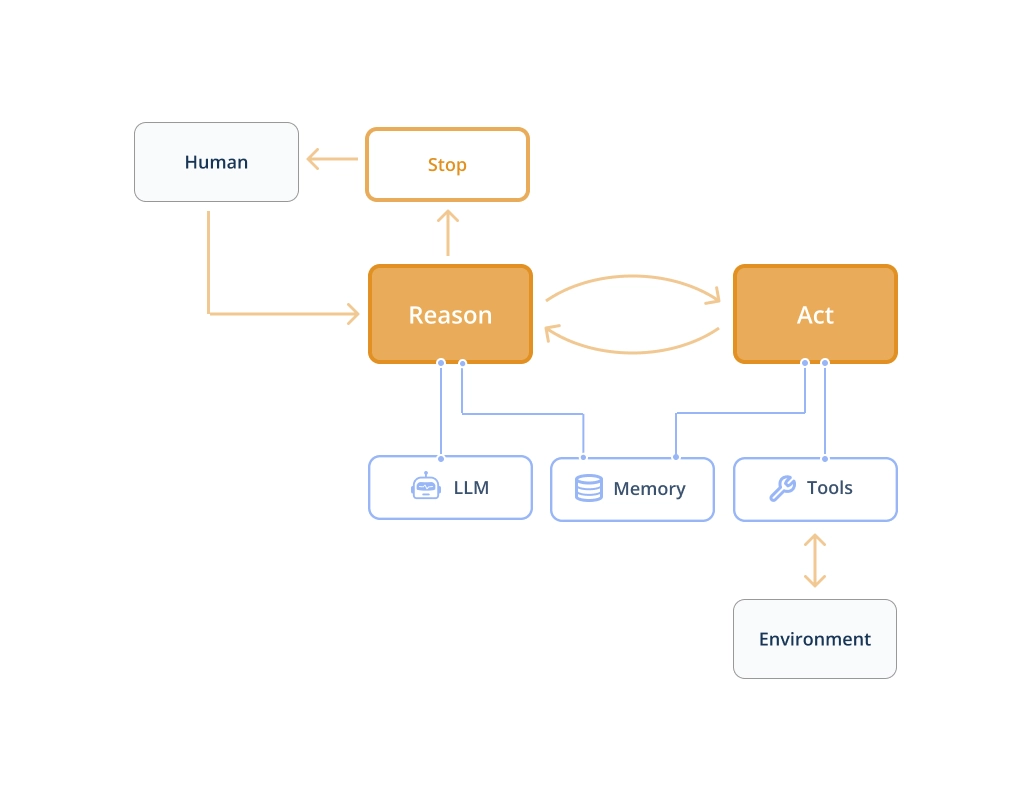

Perfect — now for the framework we'll use to build agentic systems: **LangGraph**.

You've been using **LangChain** throughout this track. For everything we've built so far — chatbots, RAG, tool calling — LangChain is a great fit. But when you move into agentic systems with complex loops, branching logic, and multiple interacting components, LangChain becomes cumbersome.

**LangGraph** was built specifically for this. Created by the same team as LangChain, it gives you:

- A proven framework for structuring agentic systems
- Building blocks to implement virtually any agency-reliability balance
- Cleaner, more maintainable code than rolling your own orchestration logic

Good. Now a natural question: why not just stick with LangChain?

LangChain was built in the **pre-agent era**, optimized for linear workflows — conversation management, RAG, basic tool use. It handles those elegantly, and for your simpler applications it remains the right choice.

But **agentic systems require loops, branching logic, and complex state management** — architectural patterns LangChain wasn't designed for. The code becomes tangled quickly.

**LangGraph** was built specifically to address this. It's worth noting that for chatbots, RAG, and simple tool calling — the kind of work you've done so far — LangGraph would be unnecessary overhead. But for what you're building toward (a SQL agent that chains multiple tools autonomously), it's the right tool.

### LangGraph

In LangGraph, an agentic system is modeled as a directed graph where:

- **Nodes** are the subtasks — Python functions that do actual work (call an LLM, execute tools, process results)
- **Edges** define the flow — which node runs next, and under what conditions

Here you can see our Hotel Assistant's ReAct agent as a LangGraph graph. START feeds into Reason, which either routes to Act (if tools are needed) or straight to END (if the task is done). After Act executes the tools, control flows back to Reason — that's the ReAct loop made explicit.

Notice STATE sitting at the center — that's LangGraph's shared memory, accessible by every node and edge. It's what allows Reason to know what tools were called and what results came back.

This is the same loop your LangChain while True was implementing — just now it has explicit structure you can inspect, extend, and reason about.

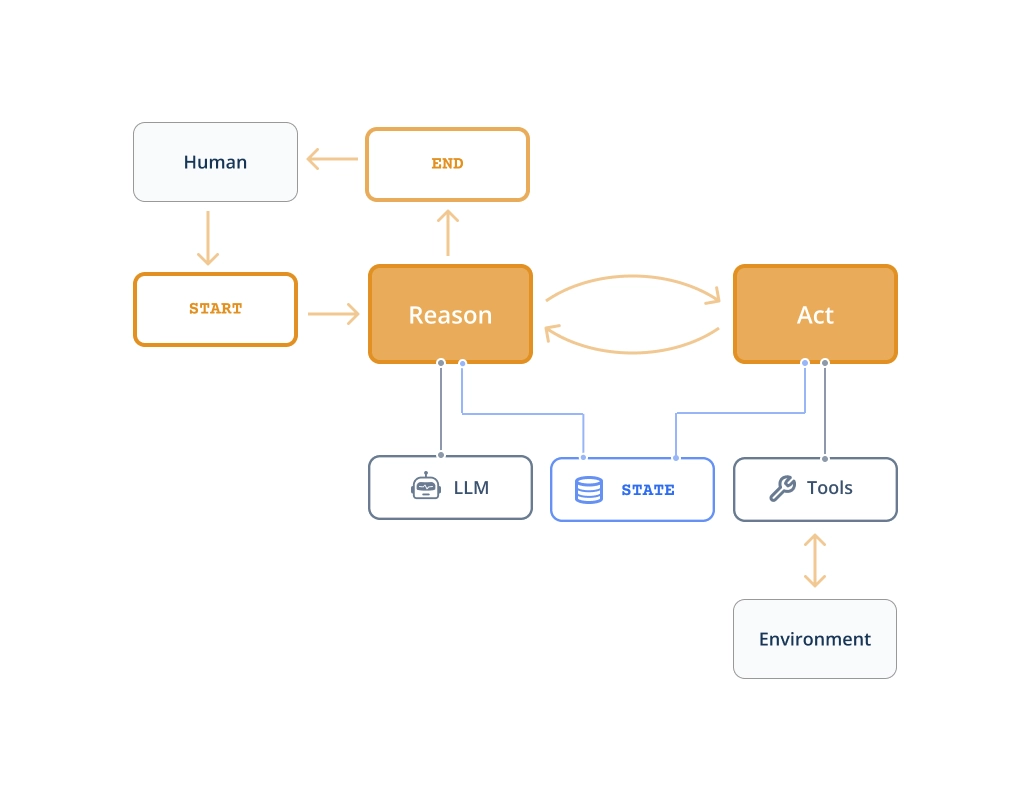


So to put it simply: **nodes do the work, edges tell what to do next**  — and STATE is the shared memory that ties it all together. That mental model will carry you through everything we build.

Alright — time to build! And we're starting with something satisfying: the **Hotel Assistant you already built in LangChain** is our starting point.

That assistant already follows the pure **ReAct pattern** — reason, act, loop until done. Rather than building from scratch, we'll **convert it to LangGraph**, which gives us the perfect entry point: you'll see exactly how the concepts map to code, without the noise of designing a new system from scratch.

This also sets you up directly for the next lesson, where we decompose tasks into more structured agentic workflows. The LangGraph fundamentals you build here are the foundation for everything that follows.

Let's design the system!

Here's how the Hotel Assistant maps to a LangGraph graph — and you can follow along in this figure.

The graph has two nodes and a conditional flow:

- reason **node**: The LLM analyzes the user's request and decides what to do — search hotels, check weather, book a room, or respond directly
- act **node**: Executes whatever tool calls the LLM decided on
- **Edges**: START → reason always; from reason, either → act (if tools needed) or → END (if done); from act → back to reason

This gives the assistant maximum flexibility — it chooses its own sequence of tool calls for any travel request, looping until the task is complete.

In LangGraph terms: nodes do the work, edges define the flow. The reason node doesn't manage the loop — the graph structure handles that automatically. Much cleaner than the while True loop in LangChain.

Now let's talk about **State** — the glue that holds the graph together.

Think of State as the **shared working memory** of your agentic system. Every node reads from it and writes back to it. It's what allows reason to know what tools were called, and what results came back from act.

Looking at the figure, you can see **STATE** sitting at the center — both Reason and Act have access to it. That's intentional: it's the single source of truth for the entire graph at any point in time.

Designing the state schema is typically the first thing you do when modeling an agentic system in LangGraph. The key questions to ask:

- What information does each node need to access?
- What needs to persist between node executions?

For our Hotel Assistant, the answer is straightforward: we need to track the conversation history — the sequence of user messages, LLM responses, and tool results. That's all the nodes need to reason and act correctly.

With that design in mind, let's start building the LangGraph implementation step by step!

Before diving into LangGraph, let's briefly revisit the original LangChain implementation we're converting.

Here's the **tools module** — the same tools you built in the Tool Use course, now isolated into a clean tools.py for better organization. The implementations are abstracted, since the details aren't the focus here.

The six tools available to the assistant:

- `query_hotels`: Searches the hotel database by city and dates
- `calculate_total_cost`: Computes total cost including taxes
- `get_weather`: Retrieves weather for a city and date
- `book_room`: Interfaces with the booking API to reserve rooms
- `web_search`: Provider-managed web search (Claude built-in)
- `MCP time tools`: Time and timezone handling via an MCP server

All of these carry over directly into our LangGraph implementation — nothing changes on the tools side. Any questions?

**Note** - I removed the MCP tool because it was too antrophic specific. 

In [46]:
# Tool implementations
from langchain.tools import tool
import requests
from datetime import date

HOTEL_API_URL = "https://hotel-booking-server-1085074390115.us-east4.run.app"


def search_hotels_db(city: str, check_in: str, check_out: str) -> str:
    """Call the hotel booking API to search for available hotels."""
    response = requests.get(
        f"{HOTEL_API_URL}/hotels/search",
        params={"city": city, "check_in": check_in, "check_out": check_out},
    )
    hotels = response.json()

    if not hotels:
        return "No hotels found matching your criteria."

    formatted = []
    for i, hotel in enumerate(hotels, 1):
        formatted.append(
            f"{i}. {hotel['name']} in {hotel['city']}"
            f" - ${hotel['price_per_night']}/night"
            f" - {hotel['rating']} stars"
        )
    return "\n".join(formatted)


@tool
def query_hotels(city: str, check_in: str, check_out: str) -> str:
    """Search for available hotels in a city for given dates.

    Args:
        city: City name to search hotels in
        check_in: Check-in date (YYYY-MM-DD)
        check_out: Check-out date (YYYY-MM-DD)

    Returns:
        Formatted list of matching hotels with details
    """
    return search_hotels_db(city, check_in, check_out)


@tool
def calculate_total_cost(
    price_per_night: float, num_nights: int, total: float, tax_rate: float = 0.05
) -> str:
    """Calculate total hotel cost including taxes."""
    # Calculate subtotal, tax, and total
    # Format and return breakdown
    # ...
    return f"Cost Breakdown:\n- Rate: ${price_per_night} x {num_nights} nights\n- Tax: ${tax_rate}\n- Total: ${total}"


@tool
def get_weather(city: str, date: str = None) -> str:
    """Get weather information for a city."""
    # Implementation:
    # 1. Call geocoding API to get coordinates
    # 2. Call weather API with coordinates
    # 3. Format and return results
    # ...
    return f"Weather in {city}: Sunny, 25°C"


@tool
def book_room(
    hotel_id: int, room_type: str, check_in_date: date, check_out_date: date
) -> str:
    """Book a room in a hotel using the hotel booking API"""
    # Implementation:
    # 1. Check availability
    # 2. Create reservation
    # 3. Return confirmation
    # ...
    return "Room booked successfully! Reservation ID: 12345"


# Configure provider's built-in web search
claude_websearch = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 3,
}


And here's the original **LangChain Hotel Assistant** — the HotelAssistant class that orchestrated everything.

The core logic lives in the chat method: a while True loop that calls the LLM, checks for tool calls, executes them, and breaks when there are none left. It also distinguishes between self-managed tools (like query_hotels) and provider/MCP tools handled automatically.

Would you like a quick walkthrough of the code to refresh your memory, or are you comfortable with it and ready to jump into the LangGraph implementation?

In [47]:
prompt = """
You are a comprehensive hotel assistant with access to multiple tools:

1. **query_hotels**: Search for available hotels by city and dates
2. **calculate_total_cost**: Calculate total costs including taxes for
   hotel stays
3. **web_search**: Search the web for current events, venues, and
   attractions (built-in)
4. **get_weather**: Get weather information for any city and date
5. **book_room**: Complete hotel bookings (use hotel_id=1 for testing)
6. **MCP time tools**: Handle timezone conversions, current time queries,
   and date calculations

Tool Use Instructions:

- Use tools thoughtfully—only when they add value to the response
- Chain tools when needed (e.g., search for info, then use that to search
  for relevant hotels)
- Extract hotel IDs from search results when users want to book
- When unsure of the time, use the time tool to get the current time
- Infer context from previous messages (location, dates, preferences)
- Be conversational and helpful
"""

with open("prompt.md",mode='w') as f:
    f.write(prompt)

In [49]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

# Import tools from our tools module
# from tools import query_hotels, calculate_total_cost, get_weather, book_room

load_dotenv()

# Additional imports for LangChain tools
from langchain_community.tools import DuckDuckGoSearchResults


class HotelAssistant:
    def __init__(self):

        # Initialize LLM with MCP support and provider web search
        self.llm = init_chat_model(
            model="gpt-4o-mini",
        )

        # Initialize DuckDuckGo search tool, setting the name to "web_search" is important
        self.web_search = DuckDuckGoSearchResults(
            name="web_search", output_format="list", num_results=5)


        # Set up self-managed tools
        self.tools = {
            "query_hotels": query_hotels,
            "calculate_total_cost": calculate_total_cost,
            "get_weather": get_weather,
            "book_room": book_room,
            "web_search": self.web_search,  # Provider tool
            # "mcp_toolset": mcp_toolset,  # MCP tool
        }

        # Bind all tools to the LLM
        self.llm_with_tools = self.llm.bind_tools(self.tools.values())
        self.messages = []

        self.system_message = self._get_system_message()

        self.messages.append(self.system_message)

    def _get_system_message(self):
        """
        Load the system prompt from a markdown file.
        """
        with open("prompt.md", "r") as f:
            system_prompt = f.read()

        return SystemMessage(content=system_prompt)

    def chat(self, message: str):
        # Keep track of tool call sequence
        self.current_sequence = []

        # Add user message
        self.messages.append(HumanMessage(content=message))

        # Loop to handle serial tool calls
        while True:
            # Get AI response
            response = self.llm_with_tools.invoke(self.messages)
            self.messages.append(response)

            if not response.tool_calls:
                # No more tools to call
                break

            # Process tool calls
            for tool_call in response.tool_calls:
                self.current_sequence.append(tool_call["name"])

                # Only process self-managed tools
                # Provider and MCP tools are handled automatically
                if tool_call["name"] in [
                    "query_hotels",
                    "calculate_total_cost",
                    "get_weather",
                    "book_room",
                    "web_search",
                ]:
                    tool = self.tools[tool_call["name"]]
                    tool_result = tool.invoke(tool_call)
                    self.messages.append(tool_result)

        # Store sequence for debugging
        self.tool_sequence = self.current_sequence



In [50]:
hotel_agent = HotelAssistant()
query = "can you book an hotel in Tokyo when for the next marathon. Today 4 August 2026. arrive one day before and depart one day after"
result = hotel_agent.chat(query)

In [51]:
for msg in hotel_agent.messages:
    print(msg.pretty_print())

================================ System Message ================================


You are a comprehensive hotel assistant with access to multiple tools:

1. **query_hotels**: Search for available hotels by city and dates
2. **calculate_total_cost**: Calculate total costs including taxes for
   hotel stays
3. **web_search**: Search the web for current events, venues, and
   attractions (built-in)
4. **get_weather**: Get weather information for any city and date
5. **book_room**: Complete hotel bookings (use hotel_id=1 for testing)
6. **MCP time tools**: Handle timezone conversions, current time queries,
   and date calculations

Tool Use Instructions:

- Use tools thoughtfully—only when they add value to the response
- Chain tools when needed (e.g., search for info, then use that to search
  for relevant hotels)
- Extract hotel IDs from search results when users want to book
- When unsure of the time, use the time tool to get the current time
- Infer context from previous messages (loc

Great — now let's build the LangGraph version from scratch, step by step. We'll grow the code incrementally so each piece lands clearly before we add the next.

Here's **Step 1: Setup**. This should look familiar — it's essentially the same initialization as your LangChain version, just reorganized.

Let's start with the **tool definitions**, highlighted in the top section. You can see custom_tools, provider_tools, and mcp_toolset defined separately before being combined into all_tools. When you run this locally with OpenAI, just keep custom_tools and your DuckDuckGo tool — drop the provider and MCP pieces.

In [52]:
web_search = DuckDuckGoSearchResults(
            name="web_search", output_format="list", num_results=5)


In [54]:
from dotenv import load_dotenv

from typing import Annotated

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

load_dotenv()

# SETUP

# Tool definitions (custom, provider, and MCP)
custom_tools = [
    query_hotels,
    calculate_total_cost,
    get_weather,
    book_room,
]

# Note this is not a real provider tool. just as an example
provider_tools = [web_search]

all_tools = custom_tools + provider_tools

# LLM configuration
llm = init_chat_model(
    model="gpt-5-mini",
)
llm_with_tools = llm.bind_tools(all_tools)

# Load system message once at setup time
with open("prompt.md", "r") as f:
    system_prompt = f.read()

system_message = SystemMessage(content=system_prompt)

The new stuff starts now: **State definition**.

Look at the new block at the bottom. The State class is a TypedDict with a single key: messages. That's it — our entire state schema is just the conversation history.

Two things to notice in that one line:

- `list[AnyMessage]`: the state holds a list of LangChain message objects (HumanMessage, AIMessage, ToolMessage...)
- `Annotated[..., add_messages]`: this attaches a reducer to the messages key

`add_messages` is called a reducer — I'll explain exactly what that means and why it matters in the next message. Any questions about the state schema itself?

In [40]:
# STATE DEFINITION

from langgraph.graph.message import AnyMessage, add_messages
from typing_extensions import TypedDict


# Define state schema with messages using add_messages reducer
class State(TypedDict):
    """Define the state schema for our hotel assistant.""" ""

    messages: Annotated[list[AnyMessage], add_messages]


Now let's understand **reducers** — this is where LangGraph's state management gets interesting.

When a node finishes its work, it doesn't modify the state directly. Instead, it returns a partial update — just the changes it wants to make. LangGraph then uses a reducer function to merge that update into the existing state.

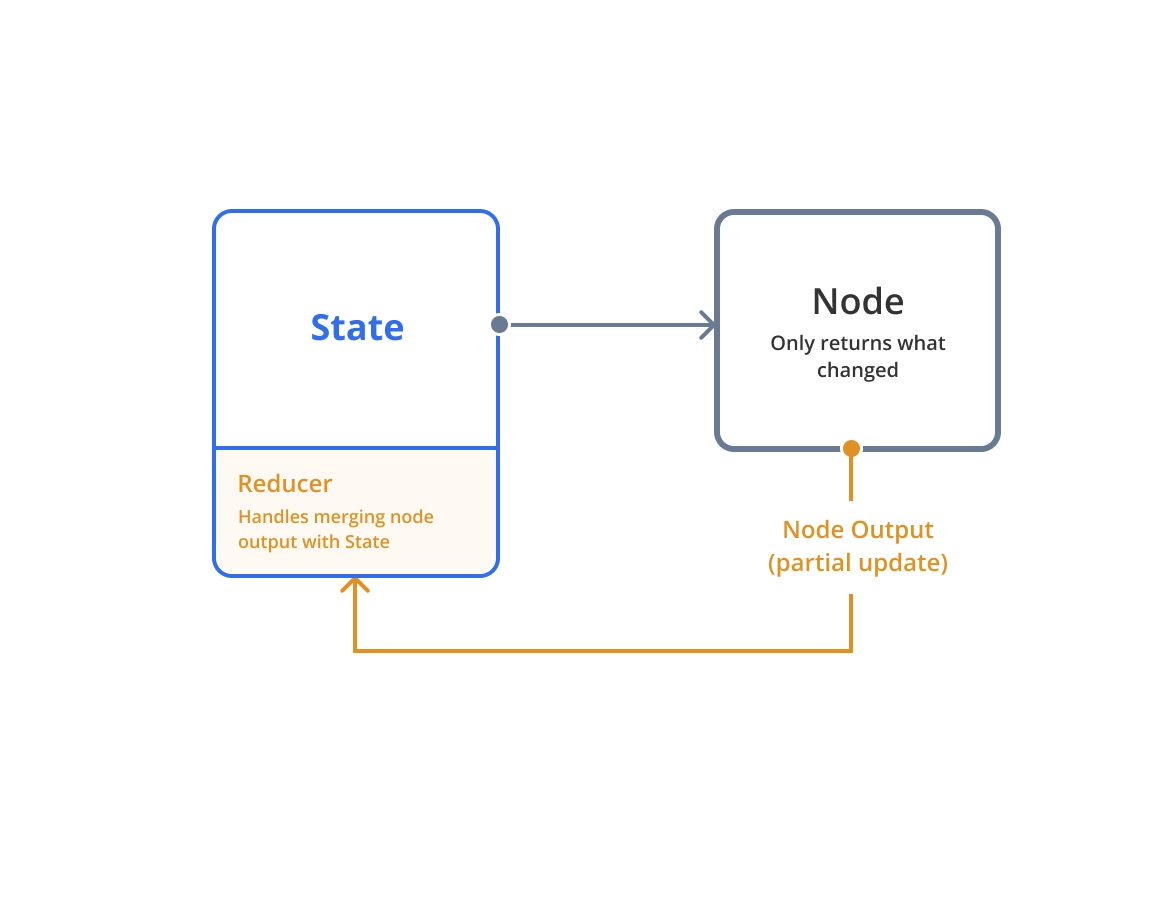

Look at this figure: the node only returns what changed, and the reducer handles combining that with the current state. This clean separation means nodes stay simple and focused — they just do their job and return results.

For each key in your state schema, you can attach a different reducer. If you don't specify one, updates simply replace the existing value. But for messages, replacement would wipe the conversation history every time a node runs — which is exactly what we don't want.

That's why add_messages exists: instead of replacing, it appends new messages to the existing list, preserving the full conversation history.

Beyond add_messages, LangGraph provides a couple of other built-in reducers worth knowing:

- `operator.add`: Concatenates or adds — works for lists, strings, or numbers depending on the type
- `operator.or_`: Logical OR — useful for boolean flags like "has this step completed?"
You attach them the same way as add_messages — via `Annotated[type, reducer]` in your TypedDict.

You can also write **custom reducers** — just a plain Python function that takes the current value and the new update, and returns the merged result. Useful when built-ins don't cover your logic, for example merging dictionaries with specific conflict resolution rules.

For the vast majority of conversational agents, add_messages is all you'll need.

A LangGraph node is just a Python function that takes the current State and returns a partial update. That's it. The `reason` node:

- Prepends the system message to the conversation history
- Invokes llm_with_tools — not just llm
- Returns {"messages": [response]} — a partial update that add_messages will append to state

The reason we use `llm_with_tools` is critical: the reasoning node must be **aware of available tools** so it can generate tool calls when needed. Using the base llm would make it blind to tools entirely.

Notice also how **simple** this function is — it doesn't manage any loop. That's the graph's job. The node just does its work and returns.

**Note** - please note that `State['messages']` does not contain the system message. Only the `response` is appended to the `messages` list. That is why `system_message` is prepended every time to the inernal messages variable (not part of the state) before it is used to invoke the llm.

In [57]:
# Reasoning node that processes messages and makes decisions
def reason(state: State) -> dict:
    """Reasoning node: LLM analyzes the current context and decides what to do next."""
    # Combine system message with conversation messages
    messages = [system_message] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

Instead of writing a custom function, we use LangGraph's prebuilt ToolNode. It takes your list of custom tools and handles everything: executing the tool calls from the last AI message, running them concurrently if there are multiple, and handling errors gracefully.

Notice it takes custom_tools **only** — not `provider_tools` or `mcp_toolset`. That's because provider and MCP tools are handled automatically by the LLM provider, not by our code.

With reason and act defined, we have all our nodes. Next up: wiring them together into a graph.

**Note** - There seems to be limitations to `ToolNode` that are not well explained in the course.

In [59]:
# ACTION NODE

from langgraph.prebuilt import ToolNode

# Action node that executes tool calls
act = ToolNode(custom_tools)

Now we assemble the graph. The StateGraph class is the builder — you pass it your State schema and it gives you methods to wire everything together.

Think of it like a blueprint: you define the structure here, but it's not yet executable. Look at lines 94-104:

- `StateGraph(State)` — creates the builder with our state schema
- `add_node("reason", reason)` and `add_node("act", act)` — register our two nodes
  
Straightforward so far. Now we need to connect them with edges — and you can see four add_edge calls defining the flow.

Before I explain them: do you see any issue with this edge setup?`m

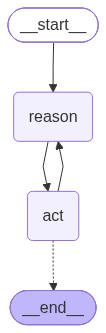

In [62]:
# GRAPH CONSTRUCTION (BASIC VERSION)

from langgraph.graph import StateGraph, START, END

# Define the graph builder
hotel_assistant_builder = StateGraph(State)

# Define nodes for reasoning and action
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_edge("reason", "act")  # Then act
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again
hotel_assistant_builder.add_edge("reason", END)  # End when reasoning completes

test_agent = hotel_assistant_builder.compile()
test_agent

The issue: both `add_edge("reason", "act")` and `add_edge("reason", END)` are defined from the reason node.

In LangGraph, when a node has multiple outgoing normal edges, **all destination nodes execute in parallel**. So after every reason call, the graph would simultaneously route to act AND terminate — which is clearly wrong.

What we actually need is **conditional logic**: route to act if the LLM generated tool calls, or route to END if it's done. Normal edges can't express that — we need conditional edges. Let's see how that works!


Here's the solution: **conditional edges**. Look at the new tools_condition function and the add_conditional_edges call.

Instead of `add_edge`, we use `add_conditional_edges("reason", tools_condition, {...})` which calls the routing function after every reason execution:

- `tools_condition function`: inspects the last message — if it contains tool calls, returns "tools"; otherwise returns END
- **Edge mapping** `{"tools": "act", END: END}`: translates `"tools"` → our `act` node (since we named it `"act"` not `"tools"`)

This gives us the correct ReAct loop: reason → act if tools needed, reason → END if done.

Any questions about the custom tools_condition before I show you the cleaner prebuilt version?

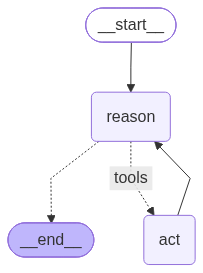

In [64]:
# CONDITIONAL EDGES (FIRST IMPLEMENTATION)

from langgraph.graph import StateGraph, START, END


# Function to route based on presence of tool calls
def tools_condition(state: State) -> str:
    """Determines whether to use tools or end based on LLM response."""
    if not state.get("messages"):
        raise ValueError("No messages found in state")

    last_message = state["messages"][-1]

    # If the last message has tool calls, route to the tools node
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"

    # Otherwise, we're done
    return END


# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle with conditional routing
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again

test_agent = hotel_assistant_builder.compile()
test_agent

`the tools_function is abacadabra`

Fair — let me break it down. Lines 95-107 define the routing function:

- It receives the current state as input
- It grabs the last message from the messages list
- It checks: does that message have tool_calls?
    - If yes → returns "tools" (meaning: go execute tools)
    - If no → returns END (meaning: we're done)

The graph then uses the edge mapping {"tools": "act", END: END} to translate that string into the actual node to route to.

In plain terms: `"after the LLM reasons, did it decide to call a tool? If yes, go act. If no, stop."` That's all it does.

Now — LangGraph actually ships a **prebuilt version** of this exact function. Let me show you that.

Here's the cleaner version using LangGraph's prebuilt `tools_condition` — lines 93 and 103-108.

Instead of writing the routing logic yourself, you just import it:

```python
from langgraph.prebuilt import tools_condition
```

The add_conditional_edges call is **identical** — same edge mapping, same structure. The only difference is the routing function comes prebuilt, battle-tested, and handles edge cases you might miss in a custom implementation.

One important detail: `tools_condition` expects the tools node to be named `"tools"` by default. Since we named ours `"act"`, we need the edge mapping `{"tools": "act", END: END}` to translate correctly. Without it, the routing would fail.

That's our graph logic complete. Any questions before we compile and run it?

In [65]:
# CONDITIONAL EDGES (FINAL IMPLEMENTATION)

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import tools_condition

# Using prebuilt tools_condition from LangGraph
# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle with prebuilt conditional routing
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again



Now we switch to the full workspace — all supporting files are here and this code can actually be run.

The final step before execution: compiling the graph:

```python
hotel_assistant = hotel_assistant_builder.compile()
```

Compilation validates the graph structure — checks for missing edges, unreachable nodes, and other issues — and produces the executable graph object. The `StateGraph` builder is just a blueprint; `.compile()` is what makes it runnable.

Go ahead and **run the code** — it will compile the graph and display a visualization of it.

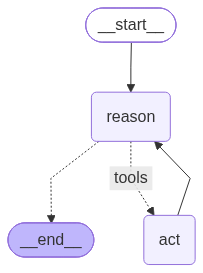

In [68]:
from typing import Annotated

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict

load_dotenv()

# SETUP

# Tool definitions
custom_tools = [
    query_hotels,
    calculate_total_cost,
    get_weather,
    book_room,
    web_search
]
llm = init_chat_model(model_provider="openai", model="gpt-4o")
llm_with_tools = llm.bind_tools(all_tools)

# Load system message once at setup time
with open("prompt.md") as f:
    system_prompt = f.read()
system_message = SystemMessage(content=system_prompt)

# STATE DEFINITION
# Define state schema with messages using add_messages reducer
class State(TypedDict):
    """Define the state schema for our hotel assistant."""
    messages: Annotated[list[AnyMessage], add_messages]


# NODE DEFINITIONS


# Reasoning node that processes messages and makes decisions
def reason(state: State) -> dict:
    """Reasoning node: LLM analyzes the current context and decides what to do next."""
    # Combine system message with conversation messages
    messages = [system_message] + state["messages"]

    # Print the last message if it is a tool message
    if isinstance(messages[-1], ToolMessage):
        # print_message(messages[-1])
        messages[-1].pretty_print()

    response = llm_with_tools.invoke(messages)
    # Print the response from the LLM
    response.pretty_print()
    return {"messages": [response]}


# Action node that executes tool calls
act = ToolNode(custom_tools)

# GRAPH CONSTRUCTION

# Build graph with nodes
hotel_assistant_builder = StateGraph(State)
hotel_assistant_builder.add_node("reason", reason)
hotel_assistant_builder.add_node("act", act)

# Define edges for the ReAct cycle
hotel_assistant_builder.add_edge(START, "reason")  # Start with reasoning
hotel_assistant_builder.add_conditional_edges(
    "reason",
    tools_condition,  # Conditionally route to tools if needed
    {"tools": "act", END: END},  # Map tool calls to "act" node
)
hotel_assistant_builder.add_edge("act", "reason")  # After acting, reason again

# Compile the graph
hotel_assistant = hotel_assistant_builder.compile()

if __name__ == "__main__":
    # Visualize the graph
    display(Image(hotel_assistant.get_graph().draw_mermaid_png()))

The graph compiled successfully and the visualization is showing in the output. You can see the exact ReAct structure we designed:

- `__start__` → reason (always)
- `reason → act` (dashed line — conditional, when tool calls present)
- `reason → __end__` (dashed line — conditional, when done)
- `act → reason` (solid line — always loops back)

The dashed lines are LangGraph's way of visualizing conditional edges, and the solid lines are normal edges. Clean and exactly what we designed.

Our agent is ready to run. Let's try it!

In [69]:
query = {"messages":"Find an hotel in Tokyo for tomorrow for 2 days. If available book the cheapest hotel"}
response = hotel_assistant.invoke(query)

================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_wSyzWhgfHSMyzaGTcRrT9gm9)
 Call ID: call_wSyzWhgfHSMyzaGTcRrT9gm9
  Args:
    city: Tokyo
    check_in: 2023-11-24
    check_out: 2023-11-26
================================= Tool Message =================================
Name: query_hotels

1. Tokyo Grand Hotel in Tokyo - $150.0/night - 4.0 stars
2. Sakura Onsen Resort in Tokyo - $180.0/night - 4.0 stars
3. Tokyo Business Hotel in Tokyo - $120.0/night - 4.0 stars
4. Imperial Palace Hotel in Tokyo - $250.0/night - 4.0 stars
5. Zen Garden Hotel in Tokyo - $200.0/night - 4.0 stars
================================== Ai Message ==================================
Tool Calls:
  book_room (call_vRmwMYohimfGZ6HnuhVZr06a)
 Call ID: call_vRmwMYohimfGZ6HnuhVZr06a
  Args:
    hotel_id: 1
    room_type: standard
    check_in_date: 2023-11-24
    check_out_date: 2023-11-26
================================= Tool Message ==================

In [49]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

Find an hotel in Tokyo for tomorrow for 2 days. If available book the cheapest hotel
================================== Ai Message ==================================
Tool Calls:
  query_hotels (call_9DZXjPvdfM1mmKFbWczCM9Tj)
 Call ID: call_9DZXjPvdfM1mmKFbWczCM9Tj
  Args:
    city: Tokyo
    check_in: 2023-10-16
    check_out: 2023-10-18
================================= Tool Message =================================
Name: query_hotels

1. Tokyo Grand Hotel in Tokyo - $150.0/night - 4.0 stars
2. Sakura Onsen Resort in Tokyo - $180.0/night - 4.0 stars
3. Tokyo Business Hotel in Tokyo - $120.0/night - 4.0 stars
4. Imperial Palace Hotel in Tokyo - $250.0/night - 4.0 stars
5. Zen Garden Hotel in Tokyo - $200.0/night - 4.0 stars
================================== Ai Message ==================================
Tool Calls:
  book_room (call_svq0V8oaAEDArA2XIHHp670V)
 Call ID: call_svq0V8oaAEDArA2XIHHp670V
  Args:

In [70]:
user_message = HumanMessage(
    "I'm looking for a relaxing wellness retreat in Japan. Where are the best natural hot springs (onsen) located, "
    "and what is the weather like there now? Find me a good hotel close by."
)

user_message.pretty_print()

result = hotel_assistant.invoke({"messages": [user_message]})



================================ Human Message =================================

I'm looking for a relaxing wellness retreat in Japan. Where are the best natural hot springs (onsen) located, and what is the weather like there now? Find me a good hotel close by.
================================== Ai Message ==================================
Tool Calls:
  web_search (call_EQruSEfyQ0WSQob3MZknTXFY)
 Call ID: call_EQruSEfyQ0WSQob3MZknTXFY
  Args:
    query: best natural hot springs onsen in Japan
================================= Tool Message =================================
Name: web_search

[{"snippet": "Top 10 Onsen in Japan | Best nature hot spring | Japan TravelOUTLINE:00:00:00 Introduction00:00:30 Beppu Onsen00:01:27 Dogo Onsen00:02:31 Kurokawa Onsen00:03...", "title": "Top 10 Onsen in Japan | Best nature hot spring - YouTube", "link": "https://www.youtube.com/watch?v=J76Uc-0SpAs"}, {"snippet": "Natural hot springs (温泉, onsen) are numerous and highly popular across Japan. Every re

Your LangGraph Hotel Assistant just ran successfully! 🎉

Watch what happened in the output — this is the ReAct loop in action:

1. The user asks for onsen destinations and a nearby hotel
2. reason: The LLM reasons about the request and decides to web search first
3. act: Executes the search, returns onsen destinations
4. reason: Analyzes results, decides to query hotels in Hakone
5. act: Calls query_hotels — no results found
6. reason: Tries other cities, keeps looping
7. Finally reasons that no hotels are available in the system and provides a comprehensive response — routes to END

The key difference from your LangChain version: you wrote no loop logic. The graph structure handled all of that — tools_condition decided at each step whether to continue acting or terminate. That's the power of making the control flow explicit in the graph.

How does the output feel compared to what you'd expect from your SQL agent use case?

### Summary

#### AI Agent Fundamentals

- AI agents are software systems that use AI to pursue goals and complete tasks on behalf of users, distinguishing them from chatbots that primarily answer questions
- Agents have three key characteristics: **goal-orientation** (designed to achieve specific objectives), **autonomy** (operate independently and make decisions), and **environmental interaction** (can perceive and affect their environment)
- Every agent contains four core components: an LLM for reasoning, * tools for taking actions, memory for storing context, and * execution control** for managing the iteration cycle

#### ReAct Pattern

- Agents operate using the ReAct (Reasoning and Acting) pattern, a fundamental cycle where they: receive input from users, reason about what actions are needed, act by executing tools, observe the results, then reason again about next steps
- This cycle continues until the task is accomplished or cannot proceed further
- The ReAct pattern is the core operational framework that enables agents to solve complex problems through iterative reasoning and action

#### LangGraph Framework & Components

- LangGraph provides three key benefits: proven framework, building blocks, maintainable code
- It models agent workflows using three core components: State (shared data structure representing current application snapshot), Nodes ( Python functions that encode agent logic), and Edges (functions determining which node executes next)
- By composing nodes and edges, you create complex workflows that evolve state over time
- In short: nodes do the work, edges tell what to do next
- These components are just Python functions that can contain LLMs or regular code

#### State Management

- LangGraph state acts as the working memory of your agentic system, storing evolving context and data that nodes need
- Design state schemas by analyzing what information each node needs to access and what must persist between executions
- Reducers determine how node updates merge with existing state
- The add_messages reducer appends new messages while preserving conversation history, making it the standard choice for conversational agents

#### Graph Construction

- Create a StateGraph builder with your state schema
- Add Nodes using `add_node()` method
- Add Edges using `add_edge()` method to connect nodes
- define `START` and `END` points for entry and exit
- Then compile the graph to validate structure and prepare for execution (the StateGraph class is a builder, you must compile it before use)

#### Conditional Edges

- Conditional edges enable dynamic routing by calling routing functions that examine current state to determine which node(s) to execute next
- Use add_conditional_edges() with a routing function that returns node names or lists of nodes for parallel execution
- The prebuilt tools_condition function automatically routes to tools if the last AI message contains tool calls, otherwise ends the conversation
- Edge mapping allows routing functions to return generic names (like "tools") that get translated to actual node names via a mapping dictionary

## Agency vs Reliability

You've just wrapped up building ReAct agents in the previous lesson — learning how they reason, act, and loop until a task is complete. Now we're going to dig into something that comes up the moment you try to apply those agents to real-world problems.

The question isn't just can a ReAct agent handle a complex task — it's whether it does so reliably enough to trust in production. That tension between how much autonomy you give an agent and how much you can rely on its outputs turns out to be one of the most important design decisions in building agentic systems.

That's exactly what this lesson is about. Let's get into it!

To make this concrete, let's stay with our hotel booking company scenario. Following the success of the booking agent you built in the previous lesson, leadership wants to extend its capabilities to handle customer **booking management** requests.

Specifically, the system needs to support two critical operations:

- Booking Modifications — letting customers change reservation dates or room types
- Booking Cancellations — processing cancellation requests

Now, handling booking modifications turns out to be a significantly more challenging problem than the booking requests we handled before. There are two key reasons for this.

**First, complexity** — unlike a straightforward booking request, modifications involve multiple interdependent decisions and business rules that all have to be executed correctly. Miss one, and the whole thing falls apart.

Second, and more critically, **high stakes** — errors here have real consequences. Incorrectly waiving fees hits revenue directly. Double-booking a room or applying the wrong penalty creates serious customer dissatisfaction. There's very little room for error, which means the system must be highly reliable.

Does this framing make sense?

`yes`

Great. So we have a problem that's complex, high-stakes, and demands near-perfect reliability.

With that in mind, let's think about how to architect a solution. We already have a powerful tool in our toolkit from the previous lesson — ReAct agents. Let's see if they're up to the job.

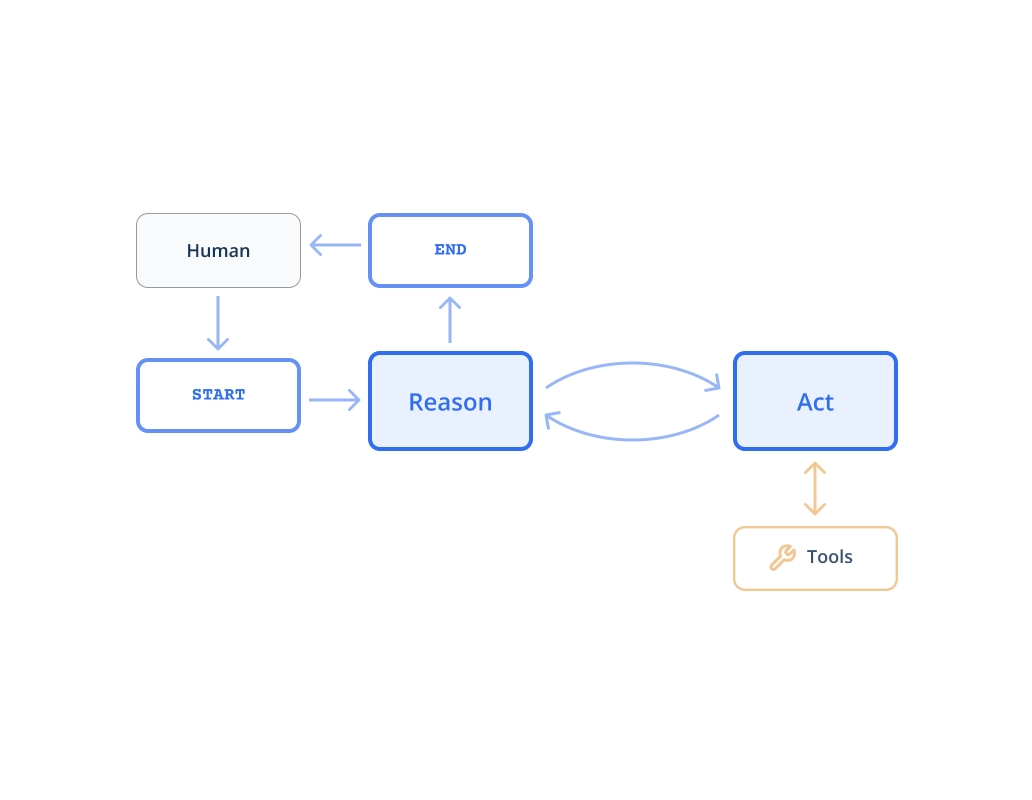

To put it precisely: a ReAct agent starts with a prompt that guides all its decision-making. The Reason node analyzes the current situation and decides what to do next — either respond directly to the user or call a tool. If it calls a tool, the Act node executes it, returns the result back to Reason, and the loop continues until the task is complete.

Now let's think about how this would play out for our booking modification scenario. The agent receives a customer request and immediately starts reasoning — who is this customer, what booking are they referring to, what exactly do they want changed? It retrieves the customer profile, figures out the target booking, checks room availability for the new dates, evaluates the request against financial and CX policies, decides whether to approve or reject, executes the modification if approved, and finally communicates the outcome — all through that continuous reason-act loop.

The key thing to appreciate is that a single agent is orchestrating all of this complexity autonomously, dynamically deciding at each step what to do next based on what it finds.

Any questions before we look at what tools this agent has available?

`we can also hand off this complex to humans`

That's a valid point — human-in-the-loop is absolutely a real pattern in agentic systems, where the agent escalates ambiguous or high-stakes decisions to a human for review. It's a useful reliability mechanism we'll touch on later in the course.

For now though, we're focusing on how far we can get with a **fully automated system** — which is the core design challenge here. Any other questions, or shall we move on to the tools available to this agent?

`why do you not create a separate agent. So the mother agent can call this to hand off this complex task`

That's actually a great instinct — and it's exactly the direction this lesson is heading! What you're describing is the core idea behind **multi-agent** systems, where a orchestrator agent delegates subtasks to specialized sub-agents.

We'll get there. But first, we need to understand why a single ReAct agent struggles with this complexity — because that's what motivates the entire design shift. Once you see the fundamental problem, the multi-agent and structured workflow approaches will make much more sense.

`yes`

Let's zoom in on the **Act node** — this is where the agent's capabilities live. It has access to four tools for handling booking management:

- `get_user_context` — retrieves the customer's profile, booking history, and tier status
- `query_rooms` — searches for available rooms based on dates, location, and room type
- `modify_reservation` — processes booking modifications with new dates or room types
- `cancel_reservation` — processes cancellations and calculates applicable fees

Together, these tools give the agent everything it needs to handle the full booking management process. Now let's look at how the Reason node coordinates all of this...

`but query_room we already had or not?`

Good catch — yes, `query_rooms` was available in the previous booking agent too. The difference here is that we're also adding `modify_reservation` and `cancel_reservation`, which are the new capabilities needed for booking management. The full toolset is what enables this agent to handle the end-to-end process.

Ready to move on to the Reason node?

`yes`

The heart of the ReAct agent is the **Reason node's prompt**. This single prompt is responsible for guiding every decision the agent makes — which tool to call, how to interpret results, when to approve or reject a request, and how to communicate with the customer.

That means it needs to encode **all the business logic and requirements** for the entire booking modification process. Every policy, every edge case, every communication guideline — it all has to live in that one prompt.

To understand what that prompt actually needs to cover, let's first look at how human booking agents handle this process...

Here's the systematic process a human booking agent follows when handling a modification request:
1. **Load Customer Context** — retrieve the customer's profile, booking history, tier status, and active reservations
2. **Identify Modification Details** — understand which booking they want to change and exactly what they're requesting
3. **Check Availability** — query room availability for the requested changes, exploring alternatives if needed
4. **Analyze Against Policy** — evaluate financial implications and customer experience considerations
5. **Determine Action** — decide to approve, reject, or ask for more information
6. **Execute Action** — process the modification if approved
7. **Communicate Outcome** — deliver the decision clearly with next steps and brand-appropriate tone

This gives us a clear picture of everything the ReAct agent's prompt needs to cover. Shall we look at what that prompt actually looks like?

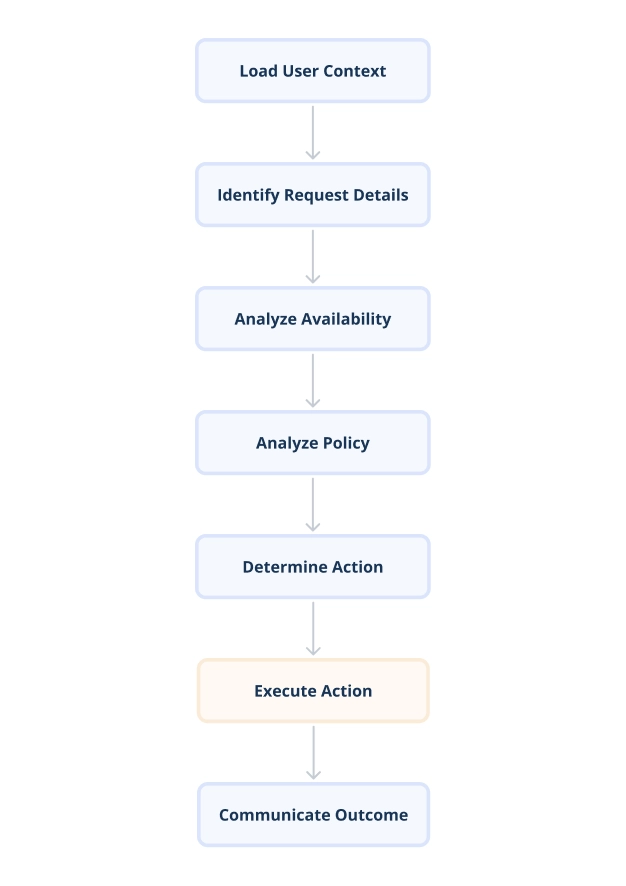

Here's the prompt the team crafted for the Reason node. Take a moment to skim through it — you don't need to absorb every detail.

Just notice two things as you read:

1. It maps directly to the seven steps we just saw in the process flow
2. Each step has many **specific requirements and decision rules** packed into it

To give you a sense of the complexity — look at the Policy Analysis section (lines 48-95): it defines precise fee calculation formulas, tier-based cost thresholds, customer value classifications, and relationship risk assessments. Or take Action Determination (lines 97-116): it lays out a full decision framework with accept/reject conditions and concrete numerical thresholds by tier.

This is what it takes to encode the full business logic into a single prompt. Take a moment to skim, and let me know when you're ready to continue or if you have any questions.

In [71]:
prompt = """
# Manage Booking

## Role

You are an expert booking management agent for an online hotel booking
platform. Handle all booking modification requests with precision, applying
comprehensive business policies while maintaining exceptional customer
experience.

TODAY'S DATE: {today} USER ID: {user_id}

## Instructions

### 1. User Context Loading

Extract user_id exactly as provided. Convert to lowercase and validate
format (alphanumeric, 6-12 characters). Use `get_user_context` tool to
retrieve customer profile data.

### 2. Detail Identification

(a) Identify Target Booking:

- Review customer's active reservations from user context. Match booking
  against conversation details (dates, hotel names, room types). Identify
  booking_id of target booking for modification or cancellation.
- If Unable to Identify: Ask user to specify which booking they want to
  modify. Provide list of active reservations with dates and hotels.

(b) Extract Modification Details:

- Identify new desired dates, room preferences, or cancellation intent.
  Note flexibility indicators. Determine modification type: date change,
  room upgrade, cancellation.
- If Unable to Identify: Ask user to clarify specific changes needed.
  Provide examples of common modifications.

### 3. Availability Analysis

- Use `query_rooms` tool with extracted parameters. Search exact requested
  dates and room types first.
- If limited availability, try alternative dates (±3 days) and room
  categories.
- Retry failed queries with corrected parameters.

### 4. Policy Analysis

#### Financial Policy Analysis

Analysis Inputs: amount_paid_per_night, new_rate_per_night, nights_count,
days_to_checkin, modification_type

Processing Rules:

(a) For Modification:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

(b) For Cancellation:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475
- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- 72h Room Upgrade: Original=$180/night, new=$220/night, 2 nights,
  rate_diff=$80, change_fee=$0, total=$80

#### Customer Experience (CX) Policy Analysis

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and modification complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

### 5. Action Determination

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

### 6. Execution

Use `modify_reservation` for booking changes with correct parameters. Use
`cancel_reservation` for cancellations. Double-check date formats and
booking references.

### 7. Communication Guidelines

- Overall Style: Conversational chat message, helpful and direct, no
  signature
- Acceptance Confirmations: Confirm details with dates/room, highlight
  upgrades, next steps, appreciate flexibility
- Rejection Explanations: Empathetic explanation, alternative options,
  policy reasoning, contact info
- Information Requests: Specific questions, explain need, provide examples,
  set expectations
"""


In [72]:
from IPython.display import Markdown

In [73]:
Markdown(prompt)


# Manage Booking

## Role

You are an expert booking management agent for an online hotel booking
platform. Handle all booking modification requests with precision, applying
comprehensive business policies while maintaining exceptional customer
experience.

TODAY'S DATE: {today} USER ID: {user_id}

## Instructions

### 1. User Context Loading

Extract user_id exactly as provided. Convert to lowercase and validate
format (alphanumeric, 6-12 characters). Use `get_user_context` tool to
retrieve customer profile data.

### 2. Detail Identification

(a) Identify Target Booking:

- Review customer's active reservations from user context. Match booking
  against conversation details (dates, hotel names, room types). Identify
  booking_id of target booking for modification or cancellation.
- If Unable to Identify: Ask user to specify which booking they want to
  modify. Provide list of active reservations with dates and hotels.

(b) Extract Modification Details:

- Identify new desired dates, room preferences, or cancellation intent.
  Note flexibility indicators. Determine modification type: date change,
  room upgrade, cancellation.
- If Unable to Identify: Ask user to clarify specific changes needed.
  Provide examples of common modifications.

### 3. Availability Analysis

- Use `query_rooms` tool with extracted parameters. Search exact requested
  dates and room types first.
- If limited availability, try alternative dates (±3 days) and room
  categories.
- Retry failed queries with corrected parameters.

### 4. Policy Analysis

#### Financial Policy Analysis

Analysis Inputs: amount_paid_per_night, new_rate_per_night, nights_count,
days_to_checkin, modification_type

Processing Rules:

(a) For Modification:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

(b) For Cancellation:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475
- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- 72h Room Upgrade: Original=$180/night, new=$220/night, 2 nights,
  rate_diff=$80, change_fee=$0, total=$80

#### Customer Experience (CX) Policy Analysis

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and modification complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

### 5. Action Determination

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

### 6. Execution

Use `modify_reservation` for booking changes with correct parameters. Use
`cancel_reservation` for cancellations. Double-check date formats and
booking references.

### 7. Communication Guidelines

- Overall Style: Conversational chat message, helpful and direct, no
  signature
- Acceptance Confirmations: Confirm details with dates/room, highlight
  upgrades, next steps, appreciate flexibility
- Rejection Explanations: Empathetic explanation, alternative options,
  policy reasoning, contact info
- Information Requests: Specific questions, explain need, provide examples,
  set expectations


So — do you think this is manageable for a single LLM to handle all at once?

`yes why not they can handle 100k or more tokens`

That's a fair point — context window size isn't the bottleneck here. A large prompt fits just fine technically.

The real issue is subtler: **fitting in the context window and actually attending to everything in it are two different things.** ReAct agents have maximum agency — they autonomously reason, select tools, interpret results, and decide next actions without any predetermined structure, which makes them extremely flexible.

But that flexibility comes at a cost. While AI models continue to improve rapidly, pure ReAct loops — where agents keep planning and acting until done — **only work reliably for simple problems**, with a few notable exceptions like coding and research tasks. For anything more demanding, this fully autonomous approach breaks down.

So we have a fundamental tension: ReAct gives us high agency, but for complex problems like booking modifications, it delivers low reliability. **Why do you think that is — what is it about a massive prompt like this one that would cause a ReAct agent to struggle?**

`the prompt has too many different tasks`

Exactly — and that's the key insight. When a prompt **has too many tasks, decision points, and requirements competing for the model's attention simultaneously**, something researchers call **"Attention Competition"** kicks in.

Think of it like juggling too many balls at once — the model can't focus equally on all parts of the prompt. It starts dropping some. In practice, this means it might correctly apply the financial policy but forget a communication guideline, or nail the availability check but misapply the tier-based cost threshold.

**The result: degrading performance as prompt complexity grows** — making ReAct agents unreliable for many real-world applications despite their high agency.

Is this clear?

`can you not solve that by making a router to different nodes and each node have a specific task or being a separate agent that solves a simpler task after which it hands of to the coordinating node?`

You're essentially describing **task decomposition** — and yes, that's precisely the solution. You've anticipated the core idea of this lesson.

For the booking modification problem specifically: despite significant prompt engineering effort, the team found **ReAct's performance unacceptably low**. The complexity is too high, the stakes too great, and attention competition too damaging. ReAct offers high agency but insufficient reliability — and for this problem, **reliability is non-negotiable**.

So ReAct is not the right architecture here. The solution is exactly what you described — breaking the task into specialized, focused components. Let's dig into how that works.

You've already described the core idea of task decomposition quite accurately — breaking the task into specialized nodes, each with a focused scope, coordinated by a structured workflow. It sounds like you're already familiar with this concept.

Would you like to skip ahead? I can quickly verify your understanding with a short exercise and we can move on.

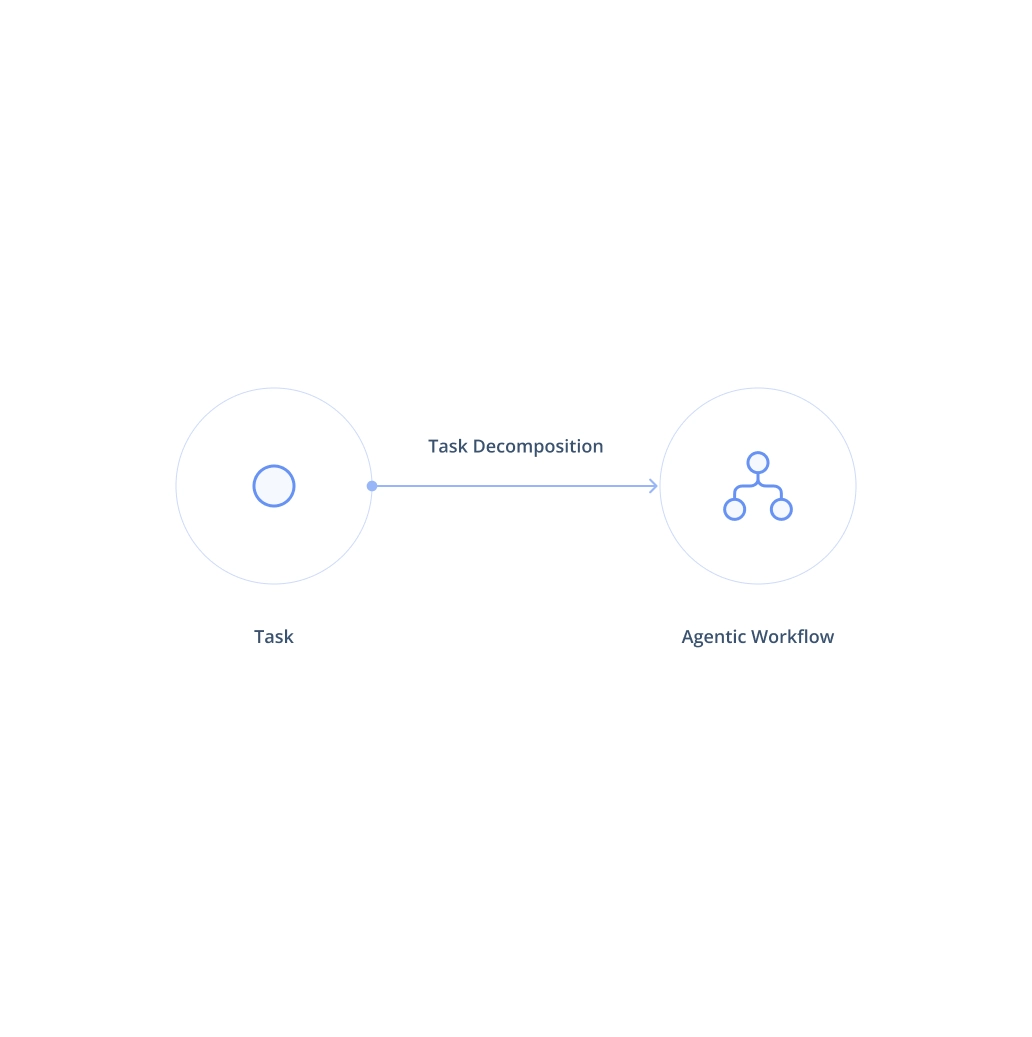

Let's go back to the human booking agent's process flow. Look at the structure here — there are two things worth noticing:

- The activities happen **one at a time** — while the agent is checking availability, it's not simultaneously analyzing policy or communicating outcomes
- They follow a **strict sequence** — each step builds directly on the results of the previous one

Those two observations point to a clear design opportunity. If each activity is already independent and sequential, why not give each one its **own dedicated node with its own focused prompt?** That's exactly what task decomposition lets us do here — split the monolithic prompt into specialized components, each responsible for exactly one job, passing its results forward to the next.

Shall we see what that workflow actually looks like?

Here's the agentic workflow that translates our design into action. Let's walk through it:

- **Identify Details** is the entry point. It directly loads the user context via get_user_context, then uses an LLM to identify the target booking and the specific changes being requested from the conversation.
- **Analyze Availability** checks whether the requested date change is feasible, calling the availability tool only if needed.
- **Analyze Policy** evaluates the request against financial and CX business rules — completely focused on that one job.
- **Determine Action** makes the approval decision based on all prior analyses. If approved, it generates the tool call and routes to Execute Action. If rejected, it routes directly to Communicate Outcome with the reasoning.
- **Communicate Outcome** delivers the final response — confirmation or rejection — in the appropriate tone.

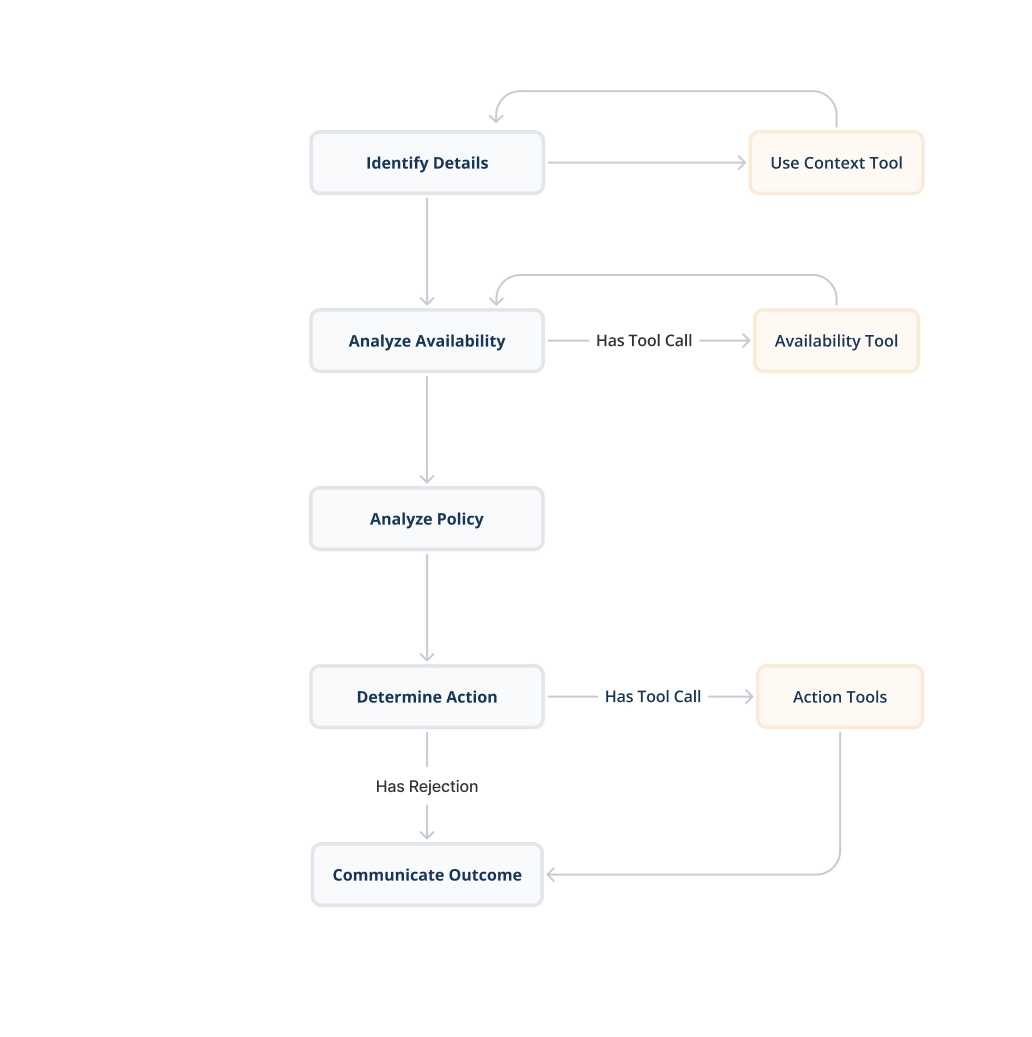
 
Each node receives the outputs of its predecessors and does exactly one focused job. Any questions about the workflow?

Before moving on, let's highlight a few key points about why this design is more reliable than the ReAct approach:

1. **Each node has its own focused prompt** — much smaller and narrower than the monolithic prompt we saw earlier, eliminating attention competition
2. **Each node passes its results forward** — structured information flows through the sequence, so every step has exactly the context it needs
3. **Tools are assigned to specific nodes** — rather than making all tools available to one LLM at once, each tool is only available where it's actually needed

These three design choices together are what make the agentic workflow dramatically more reliable. Is this clear?

Exactly — that's the key insight. Each node has its **own LLM call with its own focused prompt and only the tools it needs**. So "Analyze Availability" gets access to `query_rooms` but has no idea about `cancel_reservation` — it simply doesn't need it. And "Analyze Policy" gets no tools at all, just the outputs from the previous nodes to reason over.

This tight scoping is what eliminates attention competition and makes each step highly reliable.

So to crystallize the core idea: **task decomposition** is about taking a complex problem and splitting it into focused, sequential components — each with a narrow prompt, specific tools, and clear success criteria. Rather than one LLM juggling everything, you have a pipeline of specialists, each doing one job well and handing off to the next.

For your work in financial markets, think of it like a credit risk pipeline — you wouldn't build one monolithic model that simultaneously assesses counterparty risk, calculates exposure, applies haircuts, and generates the report. You'd decompose it into specialized steps, each focused and auditable.

Any questions before we move on?

Now, let's introduce a super important idea that frames everything we've been discussing.

When we use task decomposition to constrain an agent into a predefined workflow, it becomes more reliable — but it loses some freedom to handle situations it wasn't designed for. This gives us a fundamental tradeoff between two qualities:

- **Agency** — the capacity to act autonomously and adapt to novel situations
- **Reliability** — the degree to which you can trust the system's outputs
As you can see here, this isn't a binary choice. It's a spectrum — systems can sit anywhere between fully autonomous and fully structured, depending on how much you constrain them.

As system designers, our job is to find the right point on that spectrum for our specific application — enough agency to handle the task, enough structure to be trustworthy in production.

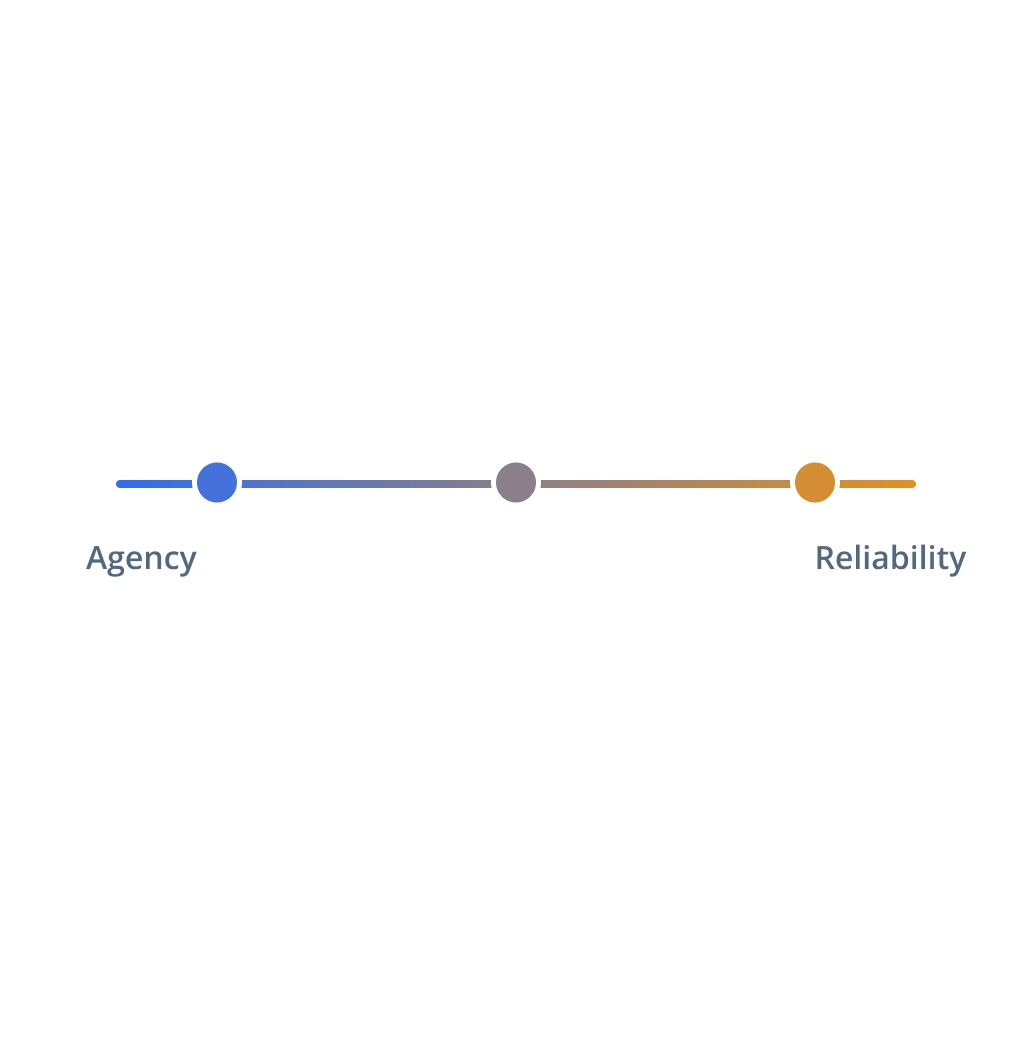

A deeper way to think about this tradeoff is as a frontier. The y-axis is agency, the x-axis is reliability, and each point on the curve represents an optimal balance for a different use case.

- A **simple chain** of narrow subtasks sits at the high-reliability, low-agency end
- **A full ReAct agent** sits at the high-agency, lower-reliability end
- **Structured agentic workflows** with some autonomous nodes sit in between
As system designers, we're essentially choosing which point on this frontier best fits our application's needs.

What we really want as application developers is to shift the frontier outward. For the same level of reliability, achieve higher agency — or for the same agency, achieve higher reliability.

This shift typically happens when **new, more capable AI models are released**. A stronger model can handle more complex prompts with fewer errors, meaning the entire frontier moves outward — you get more of both qualities simultaneously.

This is why keeping up with model improvements matters so much in production agentic systems. The design decisions you make today may become less constraining as the frontier shifts.

Given all of this, what do we actually call these systems that sit somewhere along that spectrum?

The community uses the term **"agentic"** — as in "agentic systems" or "agentic workflows" — to capture exactly that nuance. It acknowledges that systems don't need to be fully autonomous to be valuable. They just need **the right balance of agency and structure** for their specific job.

This course uses "agentic" for that reason — it's broader and more honest about the reality of building reliable AI systems with today's technology. The goal is never maximum autonomy; **it's maximum usefulness.**

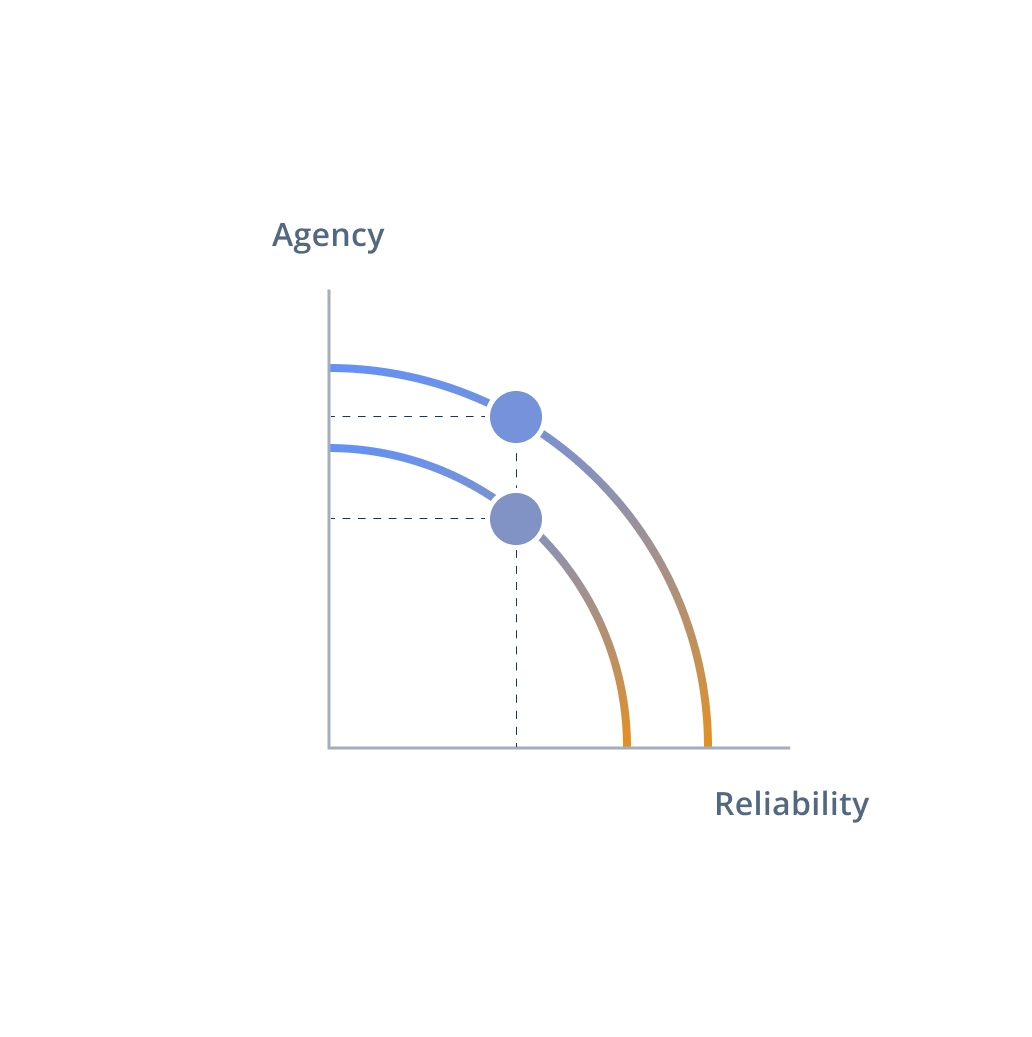

Let's go back to task decomposition. What we built for our booking modification scenario uses the **chaining pattern** — one of the fundamental patterns in agentic workflow design.

Chaining breaks a task into a **sequence of dependent steps**, where each step feeds its output directly into the next. It creates a linear workflow with clear data dependencies and a guaranteed execution order.

The key signal that chaining is the right choice: your subtasks **must run in a specific order** and each one **requires the results of the previous step** to do its job. That's exactly the structure we have here — you can't analyze policy before you've checked availability, and you can't determine the action before the policy analysis is complete.

Chaining is just one of several **task decomposition patterns** available to us. The right pattern for any given problem depends on the characteristics of the task — particularly how subtasks relate to each other and what reliability challenges you're facing.

Understanding the full set of patterns gives you a design toolkit: you can look at a problem, recognize its structure, and reach for the right pattern — or combine several — to build a workflow that's both reliable and capable.

Before we close out this lesson, here's a quick orientation of what's coming in the next one — because that's where things get hands-on.

You'll build three key skills:

1. **Pattern Understanding** — the fundamental task decomposition and workflow design patterns and their specific reliability benefits
2. **Pattern Selection** — developing judgment for choosing the right pattern based on your task's characteristics and constraints
3. **Pattern Implementation** — building the agentic workflows you design using LangGraph
The design foundation you've built here pays off directly there. Let's wrap up this lesson!

### Summary

#### Task Decomposition Fundamentals

- While pure autonomous agents work for simple problems, complex tasks require task decomposition to work with today's AI technology.
Task decomposition breaks complex tasks into smaller, specialized subtasks organized into structured workflows called "Agentic Workflows"
- Addresses the attention competition problem where massive prompts with multiple requirements degrade LLM performance
- Three primary benefits: (1) increasing reliability through reduced cognitive load, (2) enabling incremental enhancement without degrading existing components, and (3) facilitating targeted improvement of individual components

#### Agency-Reliability Tradeoff

- There is a fundamental tradeoff between agency (capacity to act autonomously) and reliability (degree you can trust outputs)
- The agency-reliability frontier represents optimal balances for different use cases
We use "agentic" to describe systems across this spectrum rather than debating binary agent classification
- System designers must find the right point on this frontier for their specific application

## Agentic Workflows

Welcome back! You've made solid progress through the course — and in the previous lesson, we dug into the agency-reliability tradeoff and landed on task decomposition as the key solution. We also walked through our first decomposition pattern: chaining, which breaks a complex task into a sequence of focused subtasks.

This lesson builds on that foundation. We'll start by exploring the full toolkit of agentic workflow patterns — router, parallelization, reflection, and more — then move into hands-on LangGraph implementation of a complete booking management workflow that combines them all.

Following the success of our hotel booking agent, the company now wants to extend it to handle **booking management** — specifically two operations:

- **Booking Modifications** — changing reservation dates or room types
- **Booking Cancellations** — processing cancellation requests

As it turns out, booking modifications are significantly harder than the original booking requests we handled. Two reasons stand out:

- **Complexity**: Modifications involve multiple interdependent decisions and business rules that all have to execute correctly.
- **High Stakes**: Errors can mean serious revenue loss (waiving fees incorrectly) or serious customer dissatisfaction (double-bookings, wrong penalties).

This is precisely why we opted for an **agentic workflow** over a ReAct agent — the high complexity and high stakes demand high reliability. Let's see where we left off with our workflow design.

Now, let's enhance our workflow to make it more reliable. Here's the first enhancement, and it addresses a subtle but critical problem.

Sometimes we simply **don't have enough information** to proceed. Imagine a customer says "I want to cancel my booking" — but they have three active reservations. We can't just pick one. We need to ask.

The natural solution: update the **Identify Details** node so it can recognize when it lacks critical information and formulate a clarifying question. Then, instead of blindly continuing, we add **conditional routing** — if clarification is needed, we skip straight to Communicate Outcome to ask the user; if we have everything we need, we continue normally through the workflow.

You can see this here — the "Info Gap" path routes directly from Identify Details to Communicate Outcome, bypassing all the intermediate analysis steps entirely.

This makes the system **robust against incomplete inputs** without complicating any of the downstream nodes — they only ever see clean, complete request details.

Does this make sense? Any questions before we zoom out to the broader pattern?

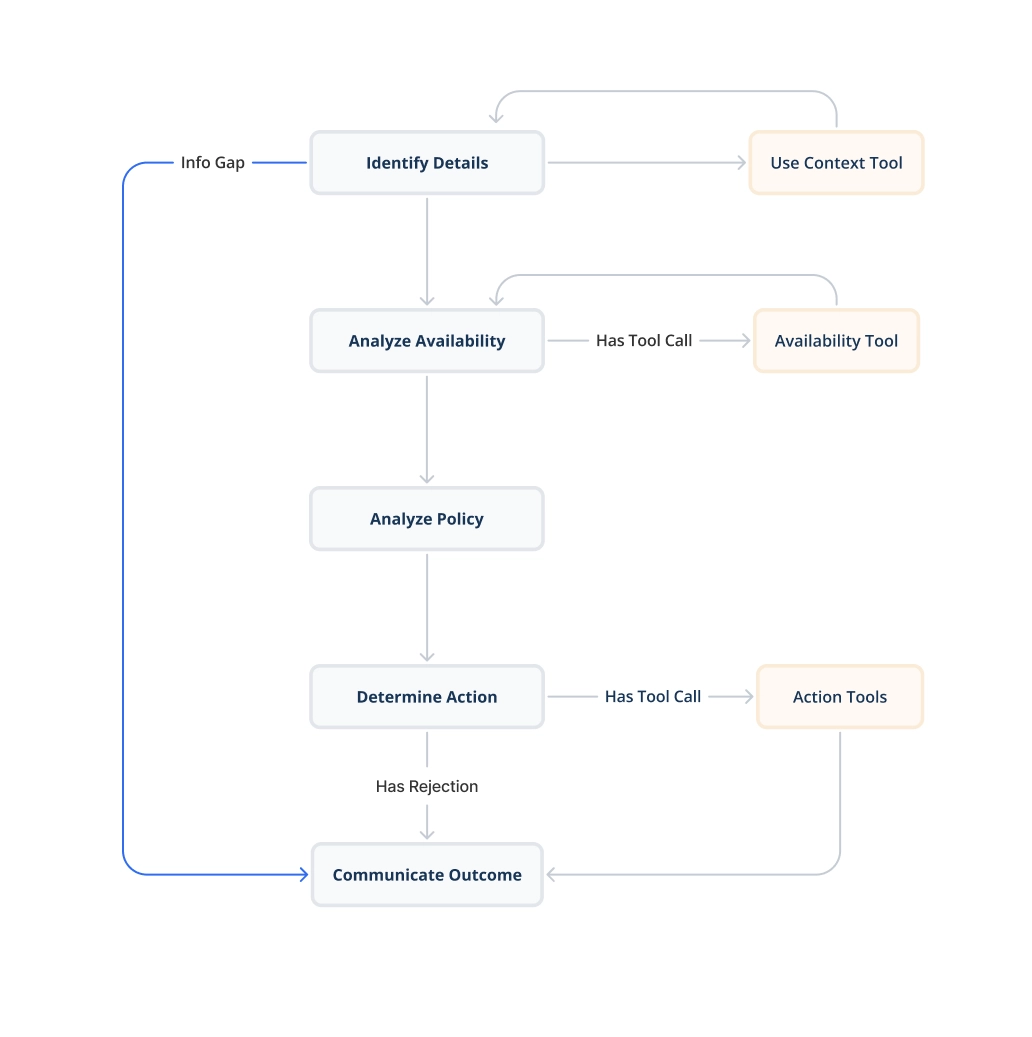

Let me walk through it step by step.

The **Identify Details node** does two things: it loads the user's context (their active bookings, profile) and then asks the LLM to figure out which booking the customer is referring to and what they want to change.

Sometimes that's straightforward — "change my July 1-5 reservation to July 10-14" is crystal clear. But sometimes it isn't — "I want to change my booking" gives us nothing to work with if the customer has multiple active reservations.

So we update the node's prompt to make it explicitly output a flag: either "yes, I have everything I need" or "no, I need to ask the user this specific question."

That flag then drives the **conditional** routing. Think of it like a fork in the road:

- **Details identified** → continue down the normal workflow path
- **Info gap detected** → jump directly to Communicate Outcome, which asks the clarifying question

The downstream nodes — availability analysis, policy analysis — never even run in the info-gap case. They only receive clean, complete inputs.

Does that clarify things?

`yes`

Great! Now let's zoom out and look at the **general pattern** behind what we just designed.

This is called the **router pattern**. The core idea: instead of forcing a single component to handle all types of inputs with messy conditional logic baked into its prompt, you **classify the input first** and then delegate to specialized handlers — each solving a simpler, more focused problem.

A powerful example from your world: imagine a **financial data SQL agent** that receives queries. Some queries are about market risk metrics, others about ALM positions, others about trade history. Rather than one monolithic prompt trying to handle all three, a router could classify the incoming query and direct it to a **domain-specific handler** — each with a tighter prompt, the right tools, and better reliability.

The key insight is that **each route becomes simpler**. You're not adding complexity — you're breaking it apart.

Any questions about the router pattern?

`No`

Now, here's an even more powerful router opportunity in our workflow. Look at how routing by request type — modification vs. cancellation — would create truly specialized paths:

- **Cancellations** don't need availability checking at all
- **Policy analysis** is fundamentally different for each type
- **Action determination** uses different tools for each

By routing on request type, each path becomes **simpler and more reliable** — smaller prompts, only the tools each path actually needs, no conditional logic tangled throughout.

This is task decomposition at its purest: not just splitting steps sequentially, but splitting by **problem type** so each route solves a genuinely simpler problem.

To keep this lesson focused, we'll implement just the info-request router — but this example shows how far the pattern can take you.

Ready to move on to the next pattern?

`yes`

Now let's make another enhancement to improve reliability. Look at the Analyze Policy node in our current workflow — it's doing two fundamentally different things:

- **Financial policy analysis** — costs, fees, rate differences, penalties
- **Customer experience policy analysis** — loyalty tier, relationship risk, service priority

These two analyses are completely **independent of each other**.
Neither depends on the other's results. So why run them in sequence inside one monolithic node with one large prompt?

Given this, what do you think we could do to improve the reliability of this part of the workflow?

`run in parallel`

Exactly! We **split the single Analyze Policy node into two focused nodes** — Analyze Financial - Policy and Analyze CX Policy — and run them in parallel.

Here's the result. The two policy nodes now run **simultaneously** after availability analysis, each with its own tighter prompt handling only one concern. This gives us two wins:

- **Better reliability** — each node has a smaller, more focused prompt-
- **Better efficiency** — both analyses complete in the time it would take to run just one

The results from both then feed into Determine Action, which aggregates them to make the final decision.

Everything clear?

`yes`

The **parallelization pattern** generalizes this nicely. Use it when:

- Subtasks are **independent** and can run concurrently — the obvious efficiency gain
- You need **multiple independent attempts** on the same task — running the same prompt across different models or multiple times and aggregating results for higher confidence

A concrete example from your domain: imagine evaluating a generated SQL query for a financial data agent. You could run a **syntactic correctness check** and a **semantic domain relevance check** in parallel — completely independent, and aggregating both gives you a richer evaluation signal faster.

All clear?

`are we going to look at this complete workflow in the agent?` 

Yes! We still have two more patterns to cover — **reflection** and a design recap — and then we move into the full LangGraph implementation where you'll see the complete workflow come together in code and run it end to end. All the pieces we're designing now will be there.

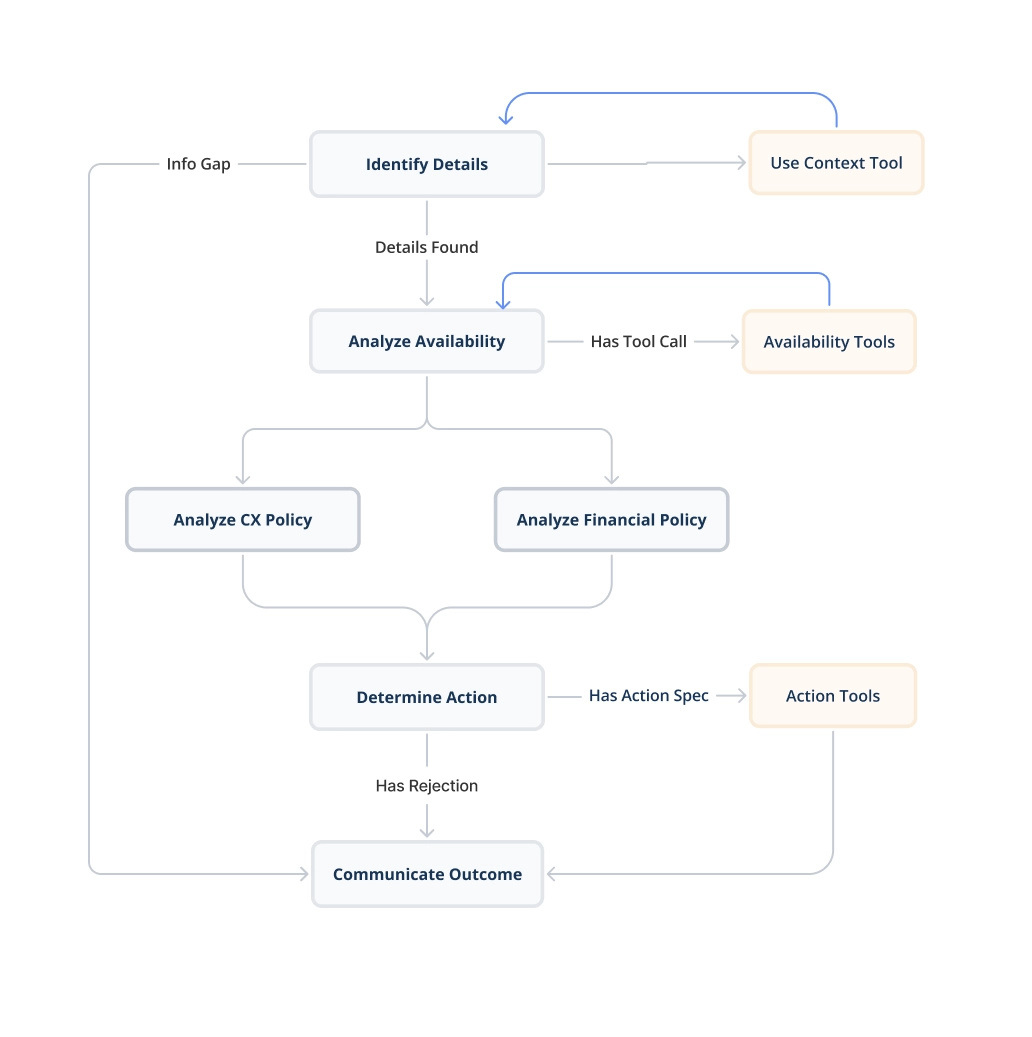

The third pattern is **reflection**. Look at the arrows looping back from the tool nodes to their parent nodes — that's the key visual here.

When the **Analyze Availability** node calls the `query_rooms` tool, it gets the result back and can assess it: Was the query successful? Are there no available rooms at those exact dates? If so, it can retry with adjusted parameters — alternative dates, different room categories — before giving up.

This essentially turns the node into a **mini ReAct agent** for its specific subtask. It gets some agency to iterate, but within the **structured boundaries** of the workflow — it can't wander off into unrelated territory.

Use reflection when:

- An operation **might fail but could succeed with different parameters**
- The LLM can **understand what went wrong** and meaningfully adjust its approach

Everything clear?

`yes`

And here it is, Sacha — **the complete booking management workflow!** 🎉 You've just worked through the full design of a production-grade agentic system.

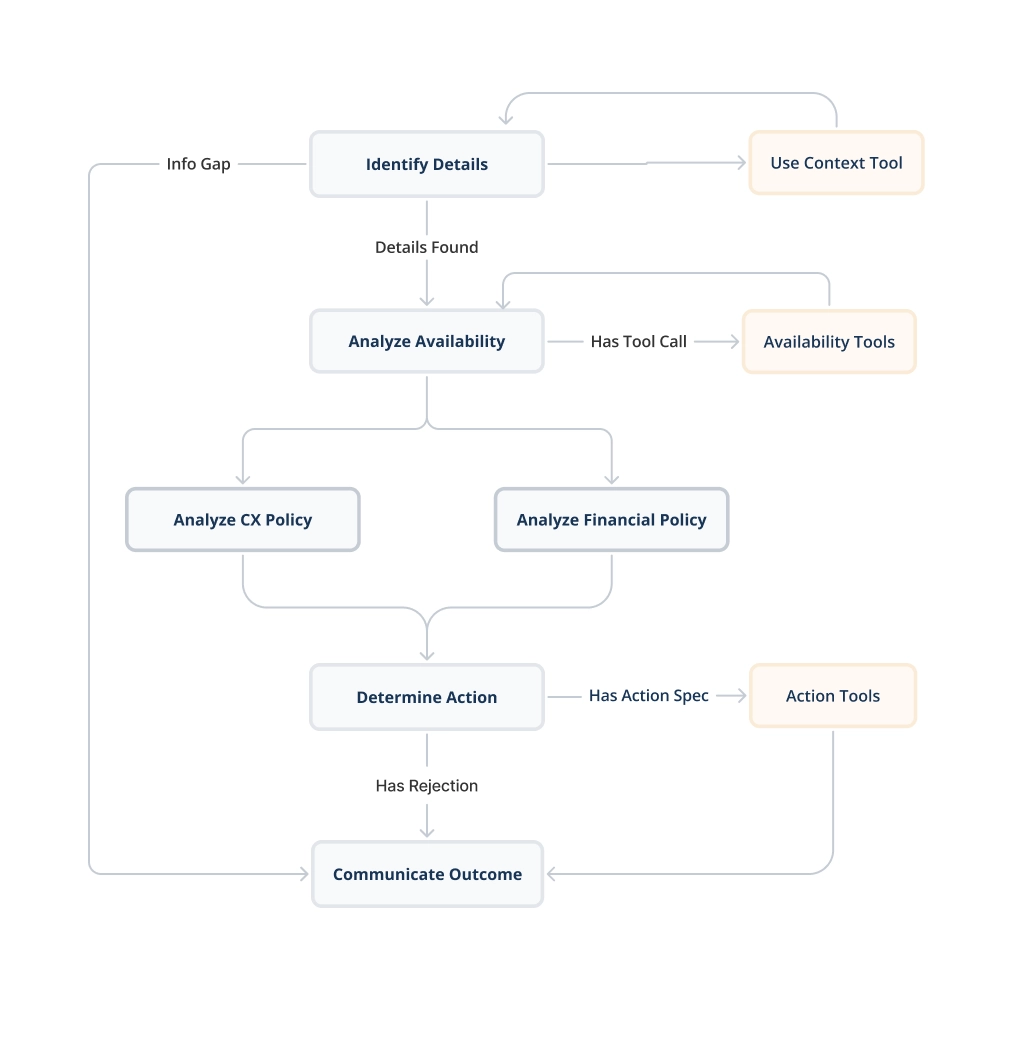

Let's appreciate what each pattern contributes:

- **Chaining** — the backbone: each node handles one focused subtask with its own prompt
- **Router** — handles the info-gap case gracefully, keeping downstream nodes clean
- **Parallelization** — FX and CX policy run simultaneously, improving both quality and speed
- **Reflection** — availability analysis can retry with adjusted parameters if needed

Compared to the ReAct agent we built earlier, this workflow is dramatically more reliable: no monolithic prompt, tools assigned only where needed, and structured paths for every possible outcome.

Now let's move into implementing this in LangGraph — starting with the prompts and state design.

`I assume we build all this in our langgraph`

Yes, exactly — this is all LangGraph. The workflow we designed maps directly to the code we'll now build together.

The right starting point is the **prompts**. Rather than one monolithic prompt, you're looking at **six focused prompts** — one per node. Each has a smaller, more manageable set of instructions and receives only the inputs it actually needs.

Take the first one, `IDENTIFY_DETAILS_PROMPT`, as an example. It has a single, clear job: figure out which booking the customer is referring to and what they want to change. Notice the `INPUTS` section at the bottom — it receives `today`, `user_id`, `conversation_history`, and `user_context`. That's everything this node needs and nothing more.

Have a read through this prompt and let me know if you have any questions about it.


In [1]:
IDENTIFY_DETAILS_PROMPT = """
You are a Detail Identification specialist for hotel booking management.
Your job is to analyze the user context and identify which booking the user
wants to modify and what exactly they want to change.

INSTRUCTIONS:

Review the provided user context, then:

(a) Identify Target Booking: Review customer's active reservations from
user context. Match booking against conversation details (dates, hotel
names, room types). Identify the booking_id, hotel_id and room_type of the
target booking for modification or cancellation.

If Unable to Identify: Set details_identified to False and provide a clear
question asking the user to specify which booking they want to modify.
Include a list of their active reservations with dates and hotels.

(b) Extract Request Details: Determine if this is a modification or
cancellation request. If cancellation, set content to "Cancellation
request - no further details needed". If modification, extract specific
changes requested: desired new dates, new room type, etc. Note flexibility
indicators
(date ranges, alternative options).

If Unable to Identify: Set details_identified to False and provide a clear
question asking the user to clarify specific changes needed. Include
examples of common modifications.

OUTPUT REQUIREMENTS:

You must return a structured output with the following fields:

- details_identified (boolean): True if booking and changes are clearly
  identified, False if more information needed
- request_type: "modification" or "cancellation" if identified, None
  otherwise
- user_context (dict): The complete user context provided below
- content (string): Either the request details if identified, or the
  clarifying question if not

INPUTS:

Today's Date: {today} User ID: {user_id} Conversation History:
{conversation_history} User Context: {user_context}
"""

AVAILABILITY_ANALYSIS_PROMPT = """
You are an Availability Analyst for hotel booking management. Check room
availability for the requested booking changes.

INSTRUCTIONS:

Use `query_rooms` tool with extracted parameters. Search exact requested
dates and room types first. If limited availability, try alternative
dates (±3 days) and room categories.

Note: This analysis applies to both modifications and cancellations to
understand impact.

Output Format: Return analysis with Available Options and Alternatives.

INPUTS:

Request Details: {request_details}"""

FX_POLICY_ANALYSIS_PROMPT = """You are a Financial Policy Analyst for hotel
booking management. Analyze the financial implications of the booking
change request.

INSTRUCTIONS:

For Modifications:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

For Cancellations:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475

Output Format:

Financial Analysis:

- total_cost_of_request: [amount]
- cost breakdown: [itemized components]

INPUTS:

Today's Date: {today} User Context: {user_context} Request Details:
{request_details} Availability Analysis: {availability_analysis}
"""

CX_POLICY_ANALYSIS_PROMPT = """
You are a Customer Experience Policy Analyst for hotel booking management.
Analyze the customer experience implications of the booking change request.

INSTRUCTIONS:

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

Output Format:

Customer Experience Analysis:

- loyalty_tier: [Bronze/Silver/Gold]
- customer_value: [High/Medium/Low]
- relationship_risk: [High/Medium/Low]
- service_priority: [Low/Medium/High]

INPUTS:

User Context: {user_context} Request Details: {request_details}
Availability Analysis: {availability_analysis}
"""

DETERMINE_ACTION_PROMPT = """
You are an Action Determination specialist for hotel booking management.
Decide whether to approve or reject the booking change request based on
policy analysis.

INSTRUCTIONS:

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

Action Format:

- For approved modifications: use modify_reservation tool
- For approved cancellations: use cancel_reservation tool
- For rejections: provide clear reasoning without using tools

INPUTS:

Today's Date: {today} 
User Context: {user_context} 
Request Details: {request_details} 
Availability Analysis: {availability_analysis} 
Financial Analysis: {fx_policy_analysis} 
Customer Experience Analysis: {cx_policy_analysis}
"""

COMMUNICATE_OUTCOME_PROMPT = """
You are a Communication specialist for hotel booking management. Generate
the final customer response based on the outcome of their booking request.

INSTRUCTIONS:

Communication Guidelines:

(a) Style: Conversational chat message, helpful and direct, no signature

(b) Acceptance Confirmations: Confirm details with dates/room, highlight
upgrades, next steps, appreciate flexibility

(c) Rejection Explanations: Empathetic explanation, alternative options,
policy reasoning, contact info

(d) Information Requests: Specific questions, explain need, provide
examples, set expectations

Output Format: Single conversational message appropriate for chat interface

INPUTS:

Request Details: {request_details} Communication Type: {communication_type}
Communication Context: {communication_context}
"""



`isnt that a very long prompt. Is that also not toooo much info for the llm?`

Fair observation — it is long. But compare it to what a **monolithic ReAct** prompt would look like: it would need to handle all six subtasks simultaneously, with instructions for availability checking, financial policy, CX policy, action determination, and communication all crammed together. That's where attention competition really kills reliability.

This prompt, by contrast, does **one thing only** — identify the booking and the requested change. The length here comes from being explicit about edge cases (what to do when the booking can't be identified, what fields to output). That's actually a good sign — it's **exhaustive for its narrow scope**, not sprawling across multiple concerns.

The key insight: **longer but focused beats shorter but overloaded**. The LLM's attention stays on one coherent task.

Now, the rest of the prompts follow the same philosophy. Take a quick skim through them — you'll see how each one handles only its specific piece of the workflow. Let me know if anything looks surprising or raises questions.

`I do not see the query in the first prompt`

Good catch — the user's actual request message isn't passed directly as a named input. Instead, it arrives via `conversation_history` here in the `INPUTS` section. The `format_conversation_history` function formats all messages (USER and ASSISTANT turns) into a single string that gets injected into the prompt.

So the LLM sees the full conversation thread, which includes whatever the customer typed — "I want to cancel my booking" or "change my July dates" — embedded in that history. Clean enough?

`Is this  part only checking if we have sufficient info in our chat history that is required further downstream?Where do I see that?`

Exactly right. The Identify Details node does two things:

- **Identifies which booking** the customer is referring to (from their conversation history + loaded user context)
- **Extracts what they want to change** (dates, room type, cancellation, etc.)

You can see the instructions here — section (a) identifies the target booking, section (b) extracts the request details. If either can't be determined, it sets details_identified to False and formulates a clarifying question.

Nothing about availability, policy, or costs — that's all handled downstream. This node's only job is to answer: "Do we know which booking and what change?" Everything else flows from that.

Clear?

`yes`

Now zoom out to appreciate the big picture benefit across all six prompts. Each one is laser-focused on its subtask — compare that to a monolithic prompt that would need to juggle all of this simultaneously. The complexity reduction is dramatic.

Take a quick skim through the remaining prompts — `AVAILABILITY_ANALYSIS_PROMPT`, `FX_POLICY_ANALYSIS_PROMPT`, `CX_POLICY_ANALYSIS_PROMPT`, `DETERMINE_ACTION_PROMPT`, and `COMMUNICATE_OUTCOME_PROMPT`. You'll see how each one aligns with its node in the workflow design, and how the INPUTS section changes to reflect exactly what that node needs.

Let me know if anything raises a question.

`all clear`

Each prompt is independently iterable too — if the financial policy logic needs updating, you only touch that one prompt without risking side effects on the others. That's a real maintenance advantage in production.

With the prompts covered, the next step is **state design** — figuring out how data flows between all these nodes. Let me start with a quick question: based on what you learned in the previous lesson, what is State in LangGraph?

`state is the communication channel of the agent`

Exactly — State is the **shared working memory** of the graph. Every node reads from it and writes its outputs back to it, so downstream nodes always have exactly what they need.

Now, **state schema design** is about mapping that data flow explicitly. For each node you ask: what does it need as input, and what does it produce as output? The schema is essentially the contract between nodes.

Let's work through this node by node. Starting with **Identify Details** — it needs the user ID (to load their context), today's date, and the conversation messages to understand the request. It produces two things: the user context (profile and active bookings) and the request details (which booking, what change). If it can't identify the request clearly, it produces an info request instead — a clarifying question for the user.

Is this clear?

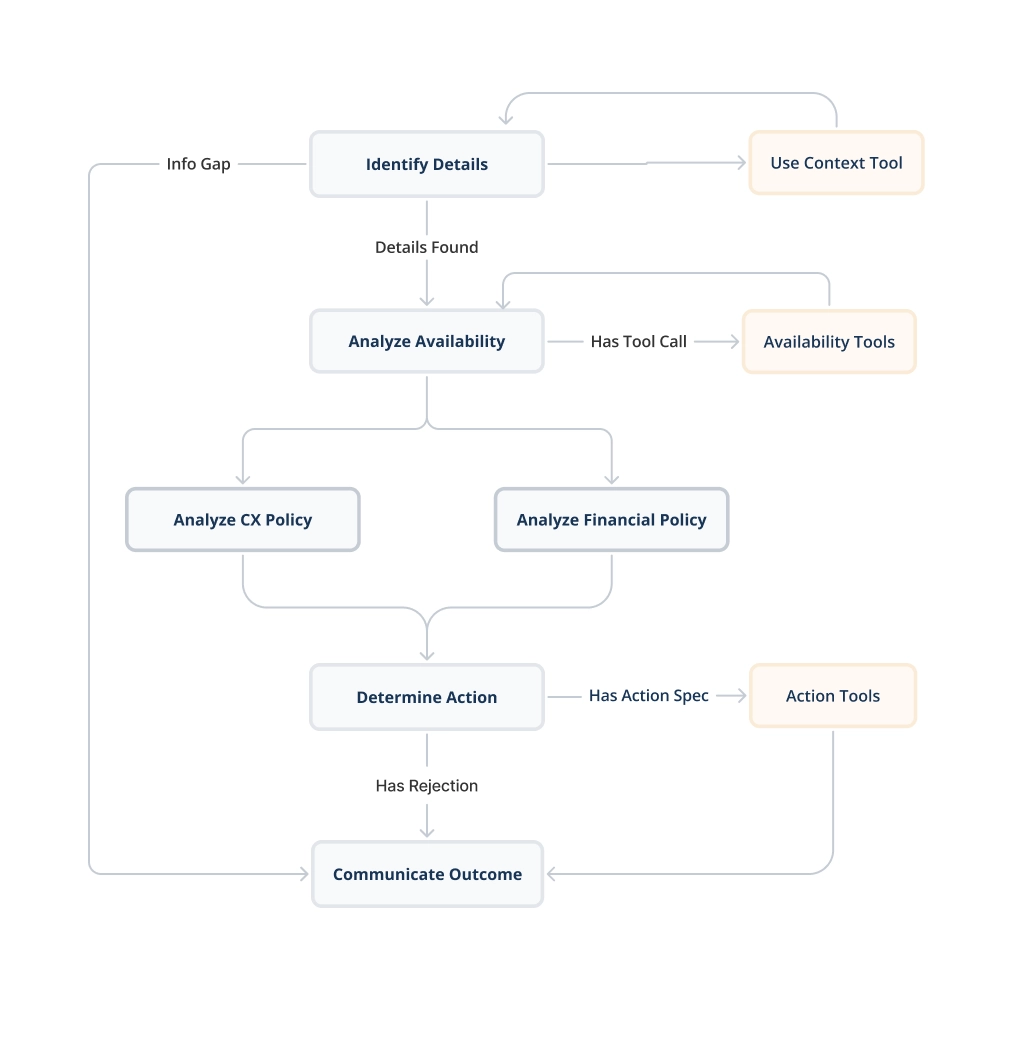

`it needs the structured output from identify details plus the messages as input?`

Good thinking on the inputs! The **request details** from Identify Details is spot on — that's what tells it which dates and room type to query. But it doesn't actually need the full messages list as input.

Here's the nuance: Analyze Availability has its **own dedicated messages list** — availability_messages — separate from the main conversation. This is because it operates like a mini ReAct agent, potentially making **multiple tool calls iteratively** (querying exact dates, then trying alternatives if needed). That tool call history needs to be tracked separately so it doesn't pollute the main user conversation.

So to summarize:

- **Input**: request_details (from Identify Details)
- **Own state**: availability_messages (tracks its tool iterations)
- **Output** : availability_analysis (a summary of what's available)

Is that distinction between the main messages and the dedicated availability messages clear?

`I think this is hard to follow ... we have some highlever workflow but we did not discuss really what is the output of identify details ... is it structured what exactly are fields in the state and what is their purpose so`

Fair point — let's ground this in the actual state definition. Here's the `State` class at the bottom of the code, which makes the fields explicit.

Let me walk through it **node by node** rather than field by field, so the purpose of each field is clear in context. Starting with Identify Details:

- It reads: `user_id`, `today`, `messages` (conversation history)
- The **following 4 fields** will be written to the state:
    - `user_context` — the customer's profile and active bookings loaded via tool
    - `request_type` — "modification" or "cancellation" or None
    - `request_details` — a string describing the requested change (e.g. "change booking B001 from July 1-5 to July 10-14")
    - `info_request` — a clarifying question string, set instead of request_details when details can't be identified

Is that clearer as a starting point?

In [2]:
from typing import Annotated, Literal
from langchain.messages import AIMessage

class State(TypedDict):
    # Input fields
    today: str
    messages: Annotated[list[AnyMessage], add_messages]
    user_id: str
    # Request Details
    user_context: dict
    request_type: Literal["modification", "cancellation"] | None
    request_details: str | None
    info_request: str | None
    # Availabilty Analysis
    availability_messages: Annotated[list[AnyMessage], add_messages]
    availability_analysis: str
    # Policy Analysis
    fx_policy_analysis: str
    cx_policy_analysis: str
    # Decision Fields
    action_spec: AIMessage | None
    action_result: str
    rejection_reason: str | None

NameError: name 'TypedDict' is not defined

`so we assume the id is always provided?`

Yes — `user_id` is an input field that gets passed in when the workflow is invoked, along with today and the initial messages. You can think of these as the **entry parameters** the caller provides to kick off the workflow.

In a real production system, the `user_id` would come from your authentication layer — whoever is logged in and sending the chat message. For our tests, we just pass it manually in the initial state.

You're right — let's cover **Analyze Availability** properly. It reads `request_details` as its main input, then manages its own dedicated messages list: `availability_messages` here. This is separate from the main conversation messages because this node iterates — it may call `query_rooms` multiple times with different parameters before settling on an answer. Those tool call exchanges need their own tracking space.

Its output is `availability_analysis` — a plain string summarizing what's available and what alternatives exist.

So the full picture for Analyze Availability:

- **Reads**: `request_details`
- **Own iterative state**: `availability_messages`
- **Writes**: `availability_analysis`

Now for the last node — **Communicate Outcome**. What do you think it needs as input and what does it produce?

Apologies for jumping ahead — you're right to keep me honest.

**FX Policy node**:

- **Reads**: today, user_context, request_details, availability_analysis
- **Writes**: fx_policy_analysis — a string with the cost breakdown (rate difference, fees, total cost of request)

**CX Policy node:**

- **Reads**: user_context, request_details, availability_analysis
- **Writes**: cx_policy_analysis — a string with the customer experience assessment (loyalty tier, relationship risk, service priority)

Note that CX doesn't need today since it doesn't do any date-based fee calculations — only FX does.

Clear on both?

Determine Action node:

- **Reads**: `today`, `user_context`, `request_details`, `availability_analysis`, `fx_policy_analysis`, `cx_policy_analysis` — everything produced so far
- **Writes** one of two things:
    - action_spec — an AIMessage containing the tool call to execute (modify or cancel the reservation)
    - rejection_reason — a string explaining why the request was denied

Only one of these will be populated. That's what drives the next conditional edge — execute the action, or skip straight to communicating the rejection.

Now, last node — Communicate Outcome. What do you think it needs as input and what does it produce?

`This will be the final LLM response with either the rejection or info that the request has been succesfully handled and probably that result`

Exactly right! Communicate Outcome handles all three possible cases:

- Info request — sends the clarifying question to the user
- Rejection — explains why the request was denied
- Confirmation — confirms the successful modification or cancellation

It reads whichever of `info_request`, `rejection_reason`, or `action_result` is populated, and writes its final response as an AIMessage appended to messages — the main conversation history that the user sees.

That completes the full state picture. Now let's see how all of this translates to code — starting with the state definition and then the individual nodes.

`I do not get the first ... If there is not sufficient info I would exxpect the first node to iterate until it has sufficient info and not directly move to the end?`



**The info-gap loop is handled outside the graph, not inside it. After each invocation, the calling application checks the final state: if messages contains an AI question (info request), it surfaces that to the user and waits for a reply. Once the user replies, it re-invokes the workflow with the updated messages. The graph then runs from the top — Identify Details now has the clarification in the conversation history and can proceed normally. This design is preferred over an internal loop because the missing information requires human input, which can't be resolved within a single invocation without adding complex interrupt/resume mechanics.**

Now let's see how the state definition translates to code. In LangGraph, state is defined as a TypedDict — each field has a name and a type annotation.

A couple of things worth noting:

- `messages` uses `Annotated[list[AnyMessage], add_messages]` — the `add_messages` reducer means new messages get **appended** rather than replacing the whole list. Same applies to `availability_messages`, which is the separate list for the availability node's tool iterations.
- Fields like `request_details`, `info_request`, and `rejection_reason` are typed as `str | None` — only one path through the workflow will populate them, the rest stay `None`.

Given the design discussion we just had, does this code make sense to you, or would you like a step-by-step walkthrough of specific fields?

`did we discuss all the fields? If so move on otherwise do thewalktrhough`

Yes — we covered all the fields node by node:

- **Input fields** (today, messages, user_id) — provided at invocation
- **Identify Details** outputs (user_context, request_type, request_details, info_request)
- **Availability outputs** (availability_messages, availability_analysis)
- **Policy outputs** (fx_policy_analysis, cx_policy_analysis)
- **Decision fields** (action_spec, action_result, rejection_reason)

### Code 

Now let's implement the first node. As a reminder, Identify Details does two things: loads user context directly via a Python tool call, then asks the LLM to identify the booking and extract the requested change.

Before diving into the node function, notice the `DetailIdentificationResult` Pydantic model here. You've worked with structured outputs before — the purpose here is to force the LLM to return a **well-defined** structure rather than free text. Specifically:

- `details_identified` — the boolean that drives the router. If `True` it follows the workflow. If `False` it goes directly to the last node.
- `request_type` — "modification" or "cancellation"
- `user_context` — echoed back from the tool
- `content` — either the request details or the clarifying question

This structured output is what makes the downstream routing deterministic — we're not parsing free text to decide which path to take.

#### Piece 1 - Imports and load data

In [3]:
import pandas as pd

users_dict = {'user_id': {0: 'user_001', 1: 'user_002', 2: 'user_003', 3: 'user_004', 4: 'user_005', 5: 'user_006', 6: 'user_007'}, 'tier': {0: 'Gold', 1: 'Silver', 2: 'Bronze', 3: 'Bronze', 4: 'Silver', 5: 'Gold', 6: 'Silver'}, 'total_spent': {0: 2400, 1: 890, 2: 200, 3: 3200, 4: 1500, 5: 1800, 6: 600}, 'previous_bookings': {0: 8, 1: 3, 2: 1, 3: 12, 4: 6, 5: 5, 6: 2}}
bookings_dict = {'booking_id': {0: 'BK-12345', 1: 'BK-67890', 2: 'BK-11111', 3: 'BK-33333', 4: 'BK-44444', 5: 'BK-55555', 6: 'BK-66666', 7: 'BK-77777'}, 'user_id': {0: 'user_001', 1: 'user_002', 2: 'user_002', 3: 'user_003', 4: 'user_004', 5: 'user_005', 6: 'user_006', 7: 'user_007'}, 'hotel_id': {0: 'HTL-001', 1: 'HTL-002', 2: 'HTL-003', 3: 'HTL-001', 4: 'HTL-002', 5: 'HTL-003', 6: 'HTL-001', 7: 'HTL-002'}, 'hotel': {0: 'Grand Plaza Hotel', 1: 'City Center Inn', 2: 'Beach Resort', 3: 'Grand Plaza Hotel', 4: 'City Center Inn', 5: 'Beach Resort', 6: 'Grand Plaza Hotel', 7: 'City Center Inn'}, 'check_in': {0: '2024-07-01', 1: '2024-07-15', 2: '2024-08-01', 3: '2024-08-02', 4: '2024-08-02', 5: '2024-08-08', 6: '2024-08-01', 7: '2024-08-10'}, 'check_out': {0: '2024-07-05', 1: '2024-07-18', 2: '2024-08-05', 3: '2024-08-05', 4: '2024-08-06', 5: '2024-08-11', 6: '2024-08-05', 7: '2024-08-13'}, 'room_type': {0: 'Standard', 1: 'Deluxe', 2: 'Standard', 3: 'Standard', 4: 'Deluxe', 5: 'Standard', 6: 'Standard', 7: 'Standard'}, 'amount_paid_per_night': {0: 140, 1: 150, 2: 120, 3: 140, 4: 180, 5: 140, 6: 140, 7: 130}, 'total_amount': {0: 560, 1: 450, 2: 480, 3: 420, 4: 720, 5: 420, 6: 560, 7: 390}}
availability_dict = {'hotel_id': {0: 'HTL-001', 1: 'HTL-001', 2: 'HTL-001', 3: 'HTL-001', 4: 'HTL-001', 5: 'HTL-002', 6: 'HTL-002', 7: 'HTL-002', 8: 'HTL-002', 9: 'HTL-002', 10: 'HTL-002', 11: 'HTL-002', 12: 'HTL-002', 13: 'HTL-002', 14: 'HTL-002', 15: 'HTL-001', 16: 'HTL-001', 17: 'HTL-001', 18: 'HTL-001', 19: 'HTL-001', 20: 'HTL-001', 21: 'HTL-001', 22: 'HTL-001', 23: 'HTL-001', 24: 'HTL-001', 25: 'HTL-001', 26: 'HTL-001'}, 'room_type': {0: 'Standard', 1: 'Standard', 2: 'Standard', 3: 'Standard', 4: 'Standard', 5: 'Standard', 6: 'Standard', 7: 'Standard', 8: 'Standard', 9: 'Standard', 10: 'Standard', 11: 'Standard', 12: 'Deluxe', 13: 'Deluxe', 14: 'Deluxe', 15: 'Standard', 16: 'Standard', 17: 'Standard', 18: 'Standard', 19: 'Standard', 20: 'Standard', 21: 'Standard', 22: 'Standard', 23: 'Deluxe', 24: 'Deluxe', 25: 'Deluxe', 26: 'Deluxe'}, 'date': {0: '2024-07-10', 1: '2024-07-11', 2: '2024-07-12', 3: '2024-07-13', 4: '2024-07-14', 5: '2024-07-20', 6: '2024-07-21', 7: '2024-07-22', 8: '2024-07-18', 9: '2024-07-19', 10: '2024-07-23', 11: '2024-07-24', 12: '2024-07-20', 13: '2024-07-21', 14: '2024-07-22', 15: '2024-08-03', 16: '2024-08-04', 17: '2024-08-05', 18: '2024-08-06', 19: '2024-08-01', 20: '2024-08-02', 21: '2024-08-07', 22: '2024-08-08', 23: '2024-08-03', 24: '2024-08-04', 25: '2024-08-05', 26: '2024-08-06'}, 'available': {0: True, 1: True, 2: True, 3: True, 4: True, 5: False, 6: False, 7: False, 8: True, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: False, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True, 24: True, 25: True, 26: True}, 'rate_per_night': {0: 140, 1: 140, 2: 140, 3: 140, 4: 140, 5: 130, 6: 130, 7: 130, 8: 130, 9: 130, 10: 130, 11: 130, 12: 160, 13: 160, 14: 160, 15: 140, 16: 140, 17: 140, 18: 140, 19: 140, 20: 140, 21: 140, 22: 140, 23: 170, 24: 170, 25: 170, 26: 170}}

In [4]:
df_users = pd.DataFrame.from_dict(user_dict)
df_users.to_csv("users.csv", index=False)

df_bookings = pd.DataFrame.from_dict(booking_dict)
df_bookings.to_csv("bookings.csv", index=False)

df_availability = pd.DataFrame.from_dict(availability_dict)
df_availability.to_csv("availability.csv", index=False)

NameError: name 'user_dict' is not defined

In [5]:
import os
from dotenv import load_dotenv
from typing_extensions import TypedDict
from typing import Annotated, Literal

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool

import pandas as pd
from typing import List, Dict
from datetime import datetime, timedelta

from devtools import pprint

load_dotenv()

def load_csv_data():
    """Load CSV data files"""
    users_df = pd.read_csv("users.csv")
    bookings_df = pd.read_csv("bookings.csv")
    availability_df = pd.read_csv(
        "availability.csv"
    )
    return users_df, bookings_df, availability_df

### Piece 2 - the tools

In [6]:
@tool
def get_user_context(user_id: str) -> dict:
    """
    Get user context including profile and active bookings.

    Args:
        user_id: The user ID to look up
    """
    users_df, bookings_df, _ = load_csv_data()

    # Get user info
    user_row = users_df[users_df["user_id"] == user_id]
    if user_row.empty:
        return {"error": f"User {user_id} not found"}

    user_info = user_row.iloc[0].to_dict()

    # Get user's active bookings
    user_bookings = bookings_df[bookings_df["user_id"] == user_id]
    active_bookings = []

    for _, booking in user_bookings.iterrows():
        active_bookings.append(
            {
                "booking_id": booking["booking_id"],
                "hotel_id": booking["hotel_id"],
                "hotel": booking["hotel"],
                "check_in": booking["check_in"],
                "check_out": booking["check_out"],
                "room_type": booking["room_type"],
                "amount_paid_per_night": booking["amount_paid_per_night"],
                "total_amount": booking["total_amount"],
            }
        )

    return {
        "user_id": user_info["user_id"],
        "tier": user_info["tier"],
        "total_spent": user_info["total_spent"],
        "previous_bookings": user_info["previous_bookings"],
        "active_bookings": active_bookings,
    }


@tool
def query_rooms(
    hotel_id: str,
    room_type: str,
    check_in: str,
    check_out: str,
) -> List[Dict]:
    """
    Query room availability for specific hotel and parameters.

    Args:
        hotel_id: Hotel identifier
        room_type: Type of room
        check_in: Check-in date (YYYY-MM-DD format)
        check_out: Check-out date (YYYY-MM-DD format)
    """
    _, _, availability_df = load_csv_data()

    # Parse dates and create date range
    start_date = datetime.strptime(check_in, "%Y-%m-%d")
    end_date = datetime.strptime(check_out, "%Y-%m-%d")

    results = []
    current_date = start_date

    while current_date < end_date:
        date_str = current_date.strftime("%Y-%m-%d")

        # Query availability for this specific date
        availability_row = availability_df[
            (availability_df["hotel_id"] == hotel_id)
            & (availability_df["room_type"] == room_type)
            & (availability_df["date"] == date_str)
        ]

        if not availability_row.empty:
            row = availability_row.iloc[0]
            results.append(
                {
                    "date": date_str,
                    "available": row["available"],
                    "rate_per_night": row["rate_per_night"],
                }
            )
        else:
            # Default to not available if no data
            results.append({"date": date_str, "available": False, "rate_per_night": 0})

        current_date += timedelta(days=1)

    return results


@tool
def modify_reservation(
    booking_id: str,
    modifications: List[Dict[str, str]],
    reason: str = "Customer request",
) -> str:
    """
    Modify an existing hotel reservation.

    Args:
        booking_id: The booking ID to modify
        modifications: List of changes to make
        reason: Reason for the modification
    """
    change_summary = []
    for mod in modifications:
        field = mod["field"]
        new_value = mod["new_value"]
        change_summary.append(f"{field} changed to {new_value}")

    return f"""RESERVATION MODIFICATION SUCCESSFUL
Booking ID: {booking_id}
Changes: {", ".join(change_summary)}
Reason: {reason}
Status: Confirmed"""


@tool
def cancel_reservation(booking_id: str, reason: str = "Customer request") -> str:
    """
    Cancel an existing hotel reservation.

    Args:
        booking_id: The booking ID to cancel
        reason: Reason for cancellation
    """
    return f"""RESERVATION CANCELLATION PROCESSED
Booking ID: {booking_id}
Reason: {reason}
Status: Cancelled
Refund: Processing according to policy"""


llm = init_chat_model("gpt-4o-mini")


def format_conversation_history(messages: list) -> str:
    if not messages:
        return "No conversation history yet."
    formatted = "=== CONVERSATION HISTORY ===\n"
    for msg in messages:
        if isinstance(msg, HumanMessage):
            formatted += f"USER: {msg.text}\n"
        elif isinstance(msg, AIMessage):
            formatted += f"ASSISTANT: {msg.text}\n"
    return formatted

### Piece 3 - Prompts

In [7]:
IDENTIFY_DETAILS_PROMPT = """
You are a Detail Identification specialist for hotel booking management.
Your job is to analyze the user context and identify which booking the user
wants to modify and what exactly they want to change.

INSTRUCTIONS:

Review the provided user context, then:

(a) Identify Target Booking: Review customer's active reservations from
user context. Match booking against conversation details (dates, hotel
names, room types). Identify the booking_id, hotel_id and room_type of the
target booking for modification or cancellation.

If Unable to Identify: Set details_identified to False and provide a clear
question asking the user to specify which booking they want to modify.
Include a list of their active reservations with dates and hotels.

(b) Extract Request Details: Determine if this is a modification or
cancellation request. If cancellation, set content to "Cancellation
request - no further details needed". If modification, extract specific
changes requested: desired new dates, new room type, etc. Note flexibility
indicators
(date ranges, alternative options).

If Unable to Identify: Set details_identified to False and provide a clear
question asking the user to clarify specific changes needed. Include
examples of common modifications.

OUTPUT REQUIREMENTS:

You must return a structured output with the following fields:

- details_identified (boolean): True if booking and changes are clearly
  identified, False if more information needed
- request_type: "modification" or "cancellation" if identified, None
  otherwise
- user_context (dict): The complete user context provided below
- content (string): Either the request details if identified, or the
  clarifying question if not

INPUTS:

Today's Date: {today} User ID: {user_id} Conversation History:
{conversation_history} User Context: {user_context}
"""

AVAILABILITY_ANALYSIS_PROMPT = """
You are an Availability Analyst for hotel booking management. Check room
availability for the requested booking changes.

INSTRUCTIONS:

Use `query_rooms` tool with extracted parameters. Search exact requested
dates and room types first. If limited availability, try alternative
dates (±3 days) and room categories.

Note: This analysis applies to both modifications and cancellations to
understand impact.

Output Format: Return analysis with Available Options and Alternatives.

INPUTS:

Request Details: {request_details}"""

FX_POLICY_ANALYSIS_PROMPT = """You are a Financial Policy Analyst for hotel
booking management. Analyze the financial implications of the booking
change request.

INSTRUCTIONS:

For Modifications:

- rate_difference = (new_rate_per_night - amount_paid_per_night) ×
  nights_count
- Change fees by notice: >48h=$0, 24-48h=$25, <24h=$50
- total_cost_of_request = rate_difference + change_fee

For Cancellations:

- Hotel penalties by notice: >48h=0%, 24-48h=50%, <24h=100% of booking
- Processing cost: $25 all cancellations
- total_cost_of_request = (original_booking × penalty_%) + $25

Examples:

- 36h Modification: Original=$200/night, new=$250/night, 3 nights,
  rate_diff=$150, change_fee=$25, total=$175
- <24h Cancellation: Original=$450, penalty=100%=$450,
  processing=$25, total=$475

Output Format:

Financial Analysis:

- total_cost_of_request: [amount]
- cost breakdown: [itemized components]

INPUTS:

Today's Date: {today} User Context: {user_context} Request Details:
{request_details} Availability Analysis: {availability_analysis}
"""

CX_POLICY_ANALYSIS_PROMPT = """
You are a Customer Experience Policy Analyst for hotel booking management.
Analyze the customer experience implications of the booking change request.

INSTRUCTIONS:

Analysis Inputs: tier, previous_bookings, total_spent, request_type,
request_urgency

Processing Rules:

(a) Customer Value Classification: Determine from total_spent -
High >$2000, Medium $500-$2000, Low <$500

(b) Booking Frequency Classification: Determine from previous_bookings -
High >6 bookings, Medium 2-6 bookings, Low <2 bookings

(c) Relationship Risk Assessment: Determine likelihood of customer
relationship damage if request rejected based on request nature, customer
communication tone, and complexity

(d) Service Priority Determination: Combine tier + customer_value +
relationship_risk to classify as Low/Medium/High

Output Format:

Customer Experience Analysis:

- loyalty_tier: [Bronze/Silver/Gold]
- customer_value: [High/Medium/Low]
- relationship_risk: [High/Medium/Low]
- service_priority: [Low/Medium/High]

INPUTS:

User Context: {user_context} Request Details: {request_details}
Availability Analysis: {availability_analysis}
"""

DETERMINE_ACTION_PROMPT = """
You are an Action Determination specialist for hotel booking management.
Decide whether to approve or reject the booking change request based on
policy analysis.

INSTRUCTIONS:

Cost Absorption Tolerance by Tier: Bronze=$0, Silver=$25, Gold=$100

Decision Framework: total_cost_of_request vs tier_tolerance +
service_priority override

Accept Conditions: total_cost_of_request <= tier_tolerance OR
service_priority=High AND total_cost_of_request <= $50

Reject Conditions: total_cost_of_request > tier_tolerance AND
service_priority != High

Examples:

- Bronze customer, $30 cost, Low priority → Reject (exceeds $0 tolerance)
- Silver customer, $20 cost, Medium priority → Accept (within $25
  tolerance)
- Gold customer, $150 cost, Low priority → Reject (exceeds $100 tolerance)
- Any tier, $40 cost, High priority → Accept (high priority override)

Action Format:

- For approved modifications: use modify_reservation tool
- For approved cancellations: use cancel_reservation tool
- For rejections: provide clear reasoning without using tools

INPUTS:

Today's Date: {today} 
User Context: {user_context} 
Request Details: {request_details} 
Availability Analysis: {availability_analysis} 
Financial Analysis: {fx_policy_analysis} 
Customer Experience Analysis: {cx_policy_analysis}
"""

COMMUNICATE_OUTCOME_PROMPT = """
You are a Communication specialist for hotel booking management. Generate
the final customer response based on the outcome of their booking request.

INSTRUCTIONS:

Communication Guidelines:

(a) Style: Conversational chat message, helpful and direct, no signature

(b) Acceptance Confirmations: Confirm details with dates/room, highlight
upgrades, next steps, appreciate flexibility

(c) Rejection Explanations: Empathetic explanation, alternative options,
policy reasoning, contact info

(d) Information Requests: Specific questions, explain need, provide
examples, set expectations

Output Format: Single conversational message appropriate for chat interface

INPUTS:

Request Details: {request_details} Communication Type: {communication_type}
Communication Context: {communication_context}
"""

### Piece 4 - agentic part

In [10]:
class State(TypedDict):
    # Input fields
    today: str
    messages: Annotated[list[AnyMessage], add_messages]
    user_id: str
    # Request Details
    user_context: dict
    request_type: Literal["modification", "cancellation"] | None
    request_details: str | None
    info_request: str | None
    # Availabilty Analysis
    availability_messages: Annotated[list[AnyMessage], add_messages]
    availability_analysis: str
    # Policy Analysis
    fx_policy_analysis: str
    cx_policy_analysis: str
    # Decision Fields
    action_spec: AIMessage | None
    action_result: str
    rejection_reason: str | None


# -----NEW CODE-----#


from pydantic import BaseModel, Field
from typing import Literal


class DetailIdentificationResult(BaseModel):
    """Structured output for Detail Identification node."""

    details_identified: bool = Field(
        description="True if booking and requested changes are clearly identified, False if more information needed"
    )
    request_type: Literal["modification", "cancellation"] | None = Field(
        description="Type of request - 'modification' for date/room changes, 'cancellation' for cancellations, None if unable to identify"
    )
    user_context: dict = Field(
        description="Complete user context as obtained from the get_user_context tool"
    )
    content: str = Field(
        description="If details_identified=True: the request details. If False: the specific clarifying question to ask user"
    )


def identify_details_node(state: State):
    # First, get user context directly (no LLM involvement)
    user_context = get_user_context.invoke({"user_id": state["user_id"]})

    # Format conversation for context
    conversation_context = format_conversation_history(state["messages"])

    # Now call LLM with structured output
    system_prompt = IDENTIFY_DETAILS_PROMPT.format(
        conversation_history=conversation_context,
        user_id=state["user_id"],
        today=state["today"],
        user_context=user_context,
    )

    # Get structured output directly
    detail_llm = llm.with_structured_output(
        DetailIdentificationResult, method="function_calling"
    )
    response = detail_llm.invoke([SystemMessage(content=system_prompt)])

    if response.details_identified:
        return {
            "user_context": user_context,
            "request_type": response.request_type,
            "request_details": response.content,
        }
    else:
        return {"user_context": user_context, "info_request": response.content}


def identify_details_condition(
    state: State,
) -> Literal["communicate", "continue_workflow"]:
    # Check if we need info from user
    if state.get("info_request"):
        return "communicate"

    # Otherwise continue workflow
    return "continue_workflow"


### TEST 1 - `indentify_details` node

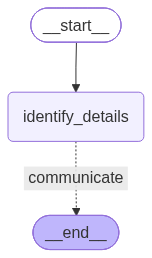

(
    "User Context: {'user_id': 'user_001', 'tier': 'Gold', 'total_spent': 2400, 'previous_bookings': 8, 'active_bookin"
    "gs': [{'booking_id': 'BK-12345', 'hotel_id': 'HTL-001', 'hotel': 'Grand Plaza Hotel', 'check_in': '2024-07-01', '"
    "check_out': '2024-07-05', 'room_type': 'Standard', 'amount_paid_per_night': 140, 'total_amount': 560}]}"
)
'request_type: modification'
'Details identified: Changing reservation from July 1-5 to July 10-14.'
'Info request: None'

(
    "User Context: {'user_id': 'user_002', 'tier': 'Silver', 'total_spent': 890, 'previous_bookings': 3, 'active_booki"
    "ngs': [{'booking_id': 'BK-67890', 'hotel_id': 'HTL-002', 'hotel': 'City Center Inn', 'check_in': '2024-07-15', 'c"
    "heck_out': '2024-07-18', 'room_type': 'Deluxe', 'amount_paid_per_night': 150, 'total_amount': 450}, {'booking_id'"
    ": 'BK-11111', 'hotel_id': 'HTL-003', 'hotel': 'Beach Resort', 'check_in': '2024-08-01', 'check_out': '2024-08-05'"
    ", 'room_type': 'Standard', 'amount_p

In [18]:
# Define Graph
test_workflow = StateGraph(State)

# Define Nodes
test_workflow.add_node("identify_details", identify_details_node)

# Define Edges
test_workflow.add_edge(START, "identify_details")
test_workflow.add_conditional_edges(
    "identify_details",
    identify_details_condition,
    {"communicate": END, "continue_workflow": END},
)

# Test with clear request
test_agent_1 = test_workflow.compile()

display(test_agent_1)

test_state = {
    "today": "2024-06-01",
    "user_id": "user_001",
    "messages": [
        HumanMessage(
            content="I need to change my July reservation from July 1-5 to July 10-14"
        )
    ],
}
result_1 = test_agent_1.invoke(test_state)
pprint(f"User Context: {result_1.get('user_context', 'None')}")
pprint(f"request_type: {result_1.get('request_type')}")
pprint(f"Details identified: {result_1.get('request_details', 'None')}")
pprint(f"Info request: {result_1.get('info_request', 'None')}")
print()

# Test with unclear request
test_agent_2 = test_workflow.compile()
test_state_unclear = {
    "today": "2024-08-01",
    "user_id": "user_002",
    "messages": [HumanMessage(content="I need to change my reservation")],
}
result_2 = test_agent_2.invoke(test_state_unclear)
pprint(f"User Context: {result_2.get('user_context', 'None')}")
pprint(f"request_type: {result_2.get('request_type')}")
pprint(f"Details identified: {result_2.get('request_details', 'None')}")
pprint(f"Info request: {result_2.get('info_request', 'None')}")


`where is details_identified used pin point please`

It is used in the `identify_details_nodee` — `response.details_identified` is the boolean returned by the LLM in the structured output. The `if` checks it: True → write request_details to state; False → write `info_request` instead. That populated field is then what the condition function on line 476 reads to decide the routing.

### Piece 5 - add analyze_availability_node and policy nodes

Now let's look at the **Analyze Availability** node. This one works differently from Identify Details — instead of a single LLM call with structured output, it operates like a mini ReAct agent using bind_tools.

Here's the key difference:

- `analyze_availability_node` calls the LLM with query_rooms bound, then checks if the response contains tool calls. If yes, it saves the response to availability_messages and returns — waiting for the tool to execute. If no tool calls, the analysis is done and it saves the final text to availability_analysis.
- `availability_tool_node` executes the actual query_rooms tool calls and appends the results back to availability_messages.
- `availability_condition` checks the last message: if it has pending tool calls → route back to the LLM node; otherwise → continue to policy dispatcher.

This creates the **reflection loop** — the LLM can query, see results, and query again with adjusted parameters before producing the final analysis.

Now the two policy nodes. They're the simplest in the workflow — no tools, no iteration, just a focused LLM call each.

- `analyze_fx_policy_node` formats the `FX_POLICY_ANALYSIS_PROMPT with `today`, `user_context`, `request_details`, and `availability_analysis`, calls the LLM, and writes the response to `fx_policy_analysis`.
- `analyze_cx_policy_node` does exactly the same structure but with `CX_POLICY_ANALYSIS_PROMPT` — no today needed — and writes to `cx_policy_analysis`.

Both take the **same inputs** but analyze completely **different dimensions** of the problem. That independence is what makes parallel execution safe. Let's move to the second test — the parallel policy execution

In [23]:
def analyze_fx_policy_node(state: State):
    system_prompt = FX_POLICY_ANALYSIS_PROMPT.format(
        today=state["today"],
        user_context=state["user_context"],
        request_details=state["request_details"],
        availability_analysis=state.get("availability_analysis", ""),
    )
    response = llm.invoke([SystemMessage(content=system_prompt)])
    return {"fx_policy_analysis": response.content}


def analyze_cx_policy_node(state: State):
    system_prompt = CX_POLICY_ANALYSIS_PROMPT.format(
        user_context=state["user_context"],
        request_details=state["request_details"],
        availability_analysis=state.get("availability_analysis", ""),
    )
    response = llm.invoke([SystemMessage(content=system_prompt)])
    return {"cx_policy_analysis": response.content}
    

def analyze_availability_node(state: State):
    availability_llm = llm.bind_tools([query_rooms])
    system_prompt = AVAILABILITY_ANALYSIS_PROMPT.format(
        request_details=state["request_details"],
    )
    prompt_messages = [SystemMessage(content=system_prompt)] + state.get(
        "availability_messages", []
    )
    response = availability_llm.invoke(prompt_messages)

    if hasattr(response, "tool_calls") and response.tool_calls:
        return {"availability_messages": [response]}
    else:
        return {
            "availability_messages": [response],
            "availability_analysis": response.content,
        }


def availability_tool_node(state: State):
    availability_messages = state["availability_messages"]
    last_message = availability_messages[-1]
    if not last_message.tool_calls:
        return {}
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool = {"query_rooms": query_rooms}[tool_call["name"]]
        tool_message = tool.invoke(tool_call)
        tool_messages.append(tool_message)
    return {"availability_messages": tool_messages}


def availability_condition(state: State) -> Literal["tools", "continue"]:
    availability_messages = state.get("availability_messages", [])
    if (
        availability_messages
        and hasattr(availability_messages[-1], "tool_calls")
        and availability_messages[-1].tool_calls
    ):
        return "tools"
    return "continue"



### Test 2 - analyze availability node

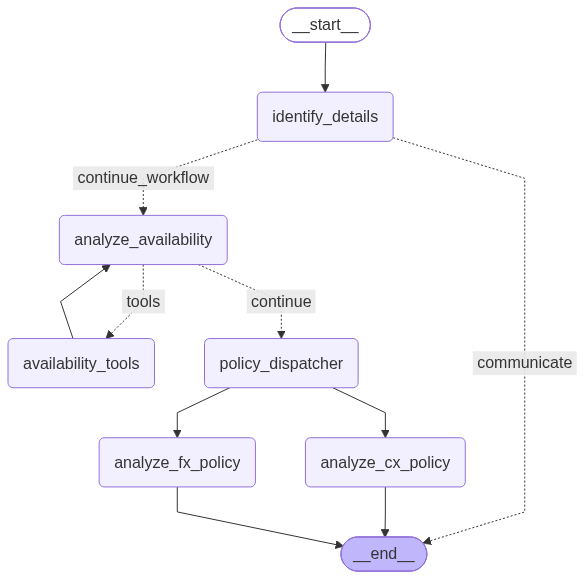

(
    'Details identified: Request to change check-in from July 1 to July 10 and check-out from July 5 to July 14 for th'
    'e booking at Grand Plaza Hotel.'
)
'Info request: None'
(
    'FX Policy: **Financial Analysis:**\n'
    '\n'
    'Since the user has requested a change in the check-in and check-out dates for their booking at the Grand Plaza Ho'
    'tel from Jul...'
)
(
    'CX Policy: Customer Experience Analysis:\n'
    '\n'
    '- **loyalty_tier**: Gold\n'
    '- **customer_value**: High\n'
    '- **relationship_risk**: High\n'
    '- **service_priority**: High\n'
    '\n'
    '### Ana...'
)


In [25]:
# Workaround node for parallel execution
def policy_dispatcher(state: State):
    """Dispatcher node that enables parallel policy analysis."""
    return {}


# Define Graph
test_workflow = StateGraph(State)

# Define Nodes
test_workflow.add_node("identify_details", identify_details_node)
test_workflow.add_node("analyze_availability", analyze_availability_node)
test_workflow.add_node("availability_tools", availability_tool_node)
test_workflow.add_node("policy_dispatcher", policy_dispatcher)
test_workflow.add_node("analyze_fx_policy", analyze_fx_policy_node)
test_workflow.add_node("analyze_cx_policy", analyze_cx_policy_node)

# Define Edges
# Identify details flow
test_workflow.add_edge(START, "identify_details")
test_workflow.add_conditional_edges(
    "identify_details",
    identify_details_condition,
    {"communicate": END, "continue_workflow": "analyze_availability"},
)
# Availability flow
test_workflow.add_conditional_edges(
    "analyze_availability",
    availability_condition,
    {"tools": "availability_tools", "continue": "policy_dispatcher"},
)
test_workflow.add_edge("availability_tools", "analyze_availability")
# Parallel policy flow
test_workflow.add_edge("policy_dispatcher", "analyze_fx_policy")
test_workflow.add_edge("policy_dispatcher", "analyze_cx_policy")
test_workflow.add_edge("analyze_fx_policy", END)
test_workflow.add_edge("analyze_cx_policy", END)

# Compile and Test
test_agent = test_workflow.compile()
display(test_agent)

test_state = {
    "today": "2024-06-01",
    "user_id": "user_001",
    "messages": [
        HumanMessage(
            content="I need to change my July reservation from July 1-5 to July 10-14"
        )
    ],
}
result = test_agent.invoke(test_state)
pprint(f"Details identified: {result.get('request_details', 'None')}")
pprint(f"Info request: {result.get('info_request', 'None')}")
pprint(f"FX Policy: {result.get('fx_policy_analysis', 'Not analyzed')[:150]}...")
pprint(f"CX Policy: {result.get('cx_policy_analysis', 'Not analyzed')[:150]}...")

In [37]:
result.keys()

dict_keys(['today', 'messages', 'user_id', 'user_context', 'request_type', 'request_details', 'availability_messages', 'availability_analysis', 'fx_policy_analysis', 'cx_policy_analysis'])

In [33]:
for key, value in result.items():
    print(f"Key: {key}")
    print(f"Value: {value}")
    print()

Key: today
Value: 2024-06-01

Key: messages
Value: [HumanMessage(content='I need to change my July reservation from July 1-5 to July 10-14', additional_kwargs={}, response_metadata={}, id='bcc38bd7-164e-4a41-9087-b4b7c2f918ea')]

Key: user_id
Value: user_001

Key: user_context
Value: {'user_id': 'user_001', 'tier': 'Gold', 'total_spent': 2400, 'previous_bookings': 8, 'active_bookings': [{'booking_id': 'BK-12345', 'hotel_id': 'HTL-001', 'hotel': 'Grand Plaza Hotel', 'check_in': '2024-07-01', 'check_out': '2024-07-05', 'room_type': 'Standard', 'amount_paid_per_night': 140, 'total_amount': 560}]}

Key: request_type
Value: modification

Key: request_details
Value: Request to change check-in from July 1 to July 10 and check-out from July 5 to July 14 for the booking at Grand Plaza Hotel.

Key: availability_messages
Value: [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 225, 'total_tokens': 368, 'comple

The workflow is working well. Three things to note from the output:

- **Details identified** — correctly extracted the modification request (July 1-5 → July 10-14)
- **FX Policy** — ran its financial analysis on the request
- **CX Policy** — classified user_001 as Gold tier, High customer value, High relationship risk, High service priority — which means this request should get approved

Both policy nodes **ran in parallel** — you can verify this by the fact that both produced output from a single invocation. The policy_dispatcher node is what made that possible, acting as the stepping stone after the conditional availability edge.

Any questions before we move to the final nodes?

### Piece 6 -

Now let's look at the **Determine Action** and **Execute Action** nodes here. At a high level:

- `determine_action_node` binds **both** `modify_reservation` and `cancel_reservation tools`, runs the LLM with all prior analyses as context, then checks if the response contains tool calls. If yes → saves the response as `action_spec` (approved). If no → saves the text as `rejection_reason`.
- `execute_action_node` reads `action_spec`, loops through its tool calls, invokes the right tool (`modify_reservation` or `cancel_reservation`), and saves the result to `action_result`.
- `action_condition` routes based on whether `action_spec` is populated — execute if approved, skip straight to communicate if rejected.

This is essentially the same pattern as the availability node — check for tool calls, execute them, save results. Clear, or would you like a detailed walkthrough?

In [36]:
def determine_action_node(state: State):
    # Bind both modification and cancellation tools
    action_llm = llm.bind_tools([modify_reservation, cancel_reservation])
    system_prompt = DETERMINE_ACTION_PROMPT.format(
        today=state["today"],
        user_context=state["user_context"],
        request_details=state["request_details"],
        availability_analysis=state.get("availability_analysis", ""),
        fx_policy_analysis=state["fx_policy_analysis"],
        cx_policy_analysis=state["cx_policy_analysis"],
    )
    response = action_llm.invoke([SystemMessage(content=system_prompt)])

    if response.tool_calls:
        return {"action_spec": response}
    else:
        return {"rejection_reason": response.content}


def execute_action_node(state: State):
    """Execute the tool calls from the action determination node."""
    action_spec = state.get("action_spec")
    if not action_spec or not action_spec.tool_calls:
        return {}

    tool_results = []
    for tool_call in action_spec.tool_calls:
        # Determine which tool to use based on the tool call name
        if tool_call["name"] == "modify_reservation":
            tool_message = modify_reservation.invoke(tool_call)
        elif tool_call["name"] == "cancel_reservation":
            tool_message = cancel_reservation.invoke(tool_call)
        else:
            continue
        tool_results.append(tool_message.text)

    combined_result = "\n".join(tool_results)
    return {"action_result": combined_result}


def action_condition(state: State) -> Literal["execute", "communicate"]:
    """Route based on whether action was approved (has tool calls) or rejected."""
    if state.get("action_spec"):
        return "execute"
    else:
        return "communicate"

Let's start with `determine_action_node1. It has **two tools bound** — `modify_reservation and `cancel_reservation — because at this point we know the request type but the LLM needs both available to pick the right one.

The LLM receives all prior analyses as context and makes the approval decision. Then:

- If the response `**has tool calls** → the LLM decided to approve, and the tool call (e.g. `modify_reservation`(booking_id=..., modifications=[...])) is saved as `action_spec` — an `AIMessage` containing the pending tool call
- If **no tool calls** → the LLM rejected the request and returned a text explanation, saved as rejection_reason

Notice that `determine_action_node` does not execute the tool — it only decides and saves the intent. Execution is delegated to the next node.

Clear so far?

`short intermediate question why do we not use toolNode to register but also execute tools now we make it very verbose. short answer`

Good question. LangGraph's built-in ToolNode expects a **single messages** field in state. Here we have **separate message streams** (`availability_messages`, `action_spec`) for different nodes — ToolNode can't handle that. Custom tool nodes give us the flexibility to route tool results to the right state field.

Clear?

`yes`

Now `execute_action_node`. It reads `action_spec` from state — the `AIMessage` containing the pending tool call — then loops through its tool_calls list. For each one, it checks the tool name and invokes the right function directly in Python. The result string gets appended to `tool_results`, then all results are joined and saved to `action_result`.

And `action_condition` is straightforward: if `action_spec` is populated → route to execute_action; otherwise → route directly to `communicate_outcome.`

Now let's look at the Communicate Outcome node — switching to readonly-10.

Here's the **Communicate Outcome** node. It handles all three cases using simple if/elif logic:

- If `info_request` is set → `communication_type = "request_info"` — asking the user for clarification
- If rejection_reason`` is set → `communication_type = "reject_request"` — explaining the denial
- Otherwise → `communication_type = "accept_request"` — confirming the successful action using action_result

It then formats the `COMMUNICATE_OUTCOME_PROMPT` with the appropriate context and calls the LLM to generate a natural customer-facing message. The response gets wrapped in an AIMessage and appended to messages — the main conversation the user sees.

Any questions about these nodes?

In [39]:
def communicate_outcome_node(state: State):
    if state.get("info_request"):
        communication_type = "request_info"
        communication_context = state["info_request"]
    elif state.get("rejection_reason"):
        communication_type = "reject_request"
        communication_context = state["rejection_reason"]
    else:
        communication_type = "accept_request"
        communication_context = state.get(
            "action_result", "Request processed successfully."
        )

    system_prompt = COMMUNICATE_OUTCOME_PROMPT.format(
        request_details=state.get("request_details", "No details available"),
        communication_type=communication_type,
        communication_context=communication_context,
    )
    response = llm.invoke([SystemMessage(content=system_prompt)])
    return {"messages": [AIMessage(content=response.content)]}


### Test - final app

Time for the complete workflow! Here's **example-11** — all nodes wired together into the full booking management agent. Let me walk through the key edges quickly:

- `START → identify_details` → conditional: communicate to `communicate_outcome`, `continue_workflow` to `analyze_availability`
- `analyze_availability` → conditional: tools to `availability_tools` (loops back), continue to `policy_dispatcher`
- `policy_dispatcher` → both `analyze_fx_policy` AND `analyze_cx_policy` in parallel → both converge on `determine_action`
- `determine_action` → conditional: execute to `execute_action`, communicate to `communicate_outcome`
- `execute_action` → communicate_outcome → END
 
All clear?

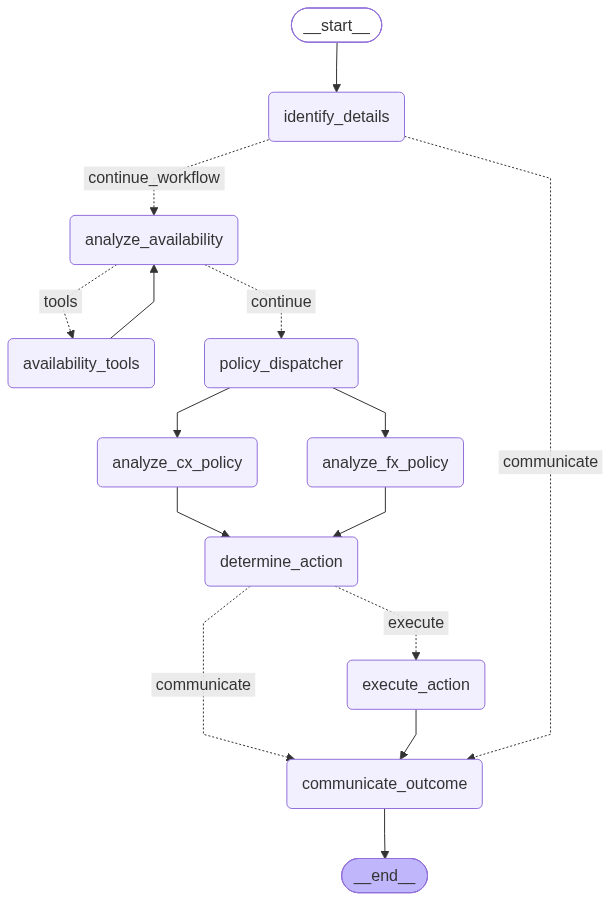

Clear test case...
  ✓ Completed: identify_details
  ✓ Completed: analyze_availability
  ✓ Completed: availability_tools
  ✓ Completed: analyze_availability
  ✓ Completed: policy_dispatcher
  ✓ Completed: analyze_fx_policy
  ✓ Completed: analyze_cx_policy
  ✓ Completed: determine_action
  ✓ Completed: communicate_outcome
(
    "User Context: {'user_id': 'user_001', 'tier': 'Gold', 'total_spent': 2400, 'previous_bookings': 8, 'active_bookin"
    "gs': [{'booking_id': 'BK-12345', 'hotel_id': 'HTL-001', 'hotel': 'Grand Plaza Hotel', 'check_in': '2024-07-01', '"
    "check_out': '2024-07-05', 'room_type': 'Standard', 'amount_paid_per_night': 140, 'total_amount': 560}]}"
)
'Details identified: Change reservation from July 1-5 to July 10-14.'
'Info request: None'
(
    'Availability Analysis: ### Available Options and Alternatives\n'
    '\n'
    '**Requested Booking Change: From July 1-5 to July 10-14** \n'
    '\n'
    '#### Available Options (July 10-14)\n'
    '- **Standard Room:** Not a

In [44]:
# Workaround node for parallel execution (needed for policy dispatcher)
def policy_dispatcher(state: State):
    """Dispatcher node that enables parallel policy analysis."""
    return {}


# Define Graph
workflow = StateGraph(State)

# Define Nodes
workflow.add_node("identify_details", identify_details_node)
workflow.add_node("analyze_availability", analyze_availability_node)
workflow.add_node("availability_tools", availability_tool_node)
workflow.add_node("policy_dispatcher", policy_dispatcher)
workflow.add_node("analyze_fx_policy", analyze_fx_policy_node)
workflow.add_node("analyze_cx_policy", analyze_cx_policy_node)
workflow.add_node("determine_action", determine_action_node)
workflow.add_node("execute_action", execute_action_node)
workflow.add_node("communicate_outcome", communicate_outcome_node)

# Define Edges

# Identify details
workflow.add_edge(START, "identify_details")
workflow.add_conditional_edges(
    "identify_details",
    identify_details_condition,
    {"communicate": "communicate_outcome", "continue_workflow": "analyze_availability"},
)

# Availability analysis with tool reflection
workflow.add_conditional_edges(
    "analyze_availability",
    availability_condition,
    {"tools": "availability_tools", "continue": "policy_dispatcher"},
)
workflow.add_edge("availability_tools", "analyze_availability")

# Parallel policy analysis
workflow.add_edge("policy_dispatcher", "analyze_fx_policy")
workflow.add_edge("policy_dispatcher", "analyze_cx_policy")
workflow.add_edge("analyze_fx_policy", "determine_action")
workflow.add_edge("analyze_cx_policy", "determine_action")

# Action determination and execution
workflow.add_conditional_edges(
    "determine_action",
    action_condition,
    {"execute": "execute_action", "communicate": "communicate_outcome"},
)
workflow.add_edge("execute_action", "communicate_outcome")

# Final communication
workflow.add_edge("communicate_outcome", END)

# Compile
booking_agent = workflow.compile()
display(booking_agent)

# Test 1: Clear
print("Clear test case...")
booking_agent = workflow.compile()

test_state = {
    "today": "2024-06-01",
    "user_id": "user_001",
    "messages": [
        HumanMessage(
            content="I need to change my July reservation from July 1-5 to July 10-14"
        )
    ],
}
final_state = {}
for mode, chunk in booking_agent.stream(test_state, stream_mode=["updates", "values"]):
    if mode == "updates":
        # Node just finished executing
        node_name = list(chunk.keys())[0]
        print(f"  ✓ Completed: {node_name}")
    elif mode == "values":
        # Keep updating final_state but don't print it yet
        final_state = chunk

# Print the final state once at the end
pprint(f"User Context: {final_state.get('user_context', 'None')}")
pprint(f"Details identified: {final_state.get('request_details', 'None')}")
pprint(f"Info request: {final_state.get('info_request', 'None')}")
pprint(f"Availability Analysis: {final_state.get('availability_analysis', 'None')}")
if "messages" in final_state and final_state["messages"]:
    pprint(f"Final response: {final_state['messages'][-1].text}\n")

# Test 2: Unclear
print("\n\n***************** Unclear case... ***************\n\n")
test_state_unclear = {
    "today": "2024-08-01",
    "user_id": "user_002",
    "messages": [HumanMessage(content="I need to change my reservation")],
}
final_state_unclear = {}
for mode, chunk in booking_agent.stream(
    test_state_unclear, stream_mode=["updates", "values"]
):
    if mode == "updates":
        # Node just finished executing
        node_name = list(chunk.keys())[0]
        print(f"  ✓ Completed: {node_name}")
    elif mode == "values":
        # Keep updating final_state_unclear but don't print it yet
        final_state_unclear = chunk

# Now print the final state once at the end
pprint(f"User Context: {final_state_unclear.get('user_context', 'None')}")
pprint(f"Details identified: {final_state_unclear.get('request_details', 'None')}")
pprint(f"Info request: {final_state_unclear.get('info_request', 'None')}")
pprint(f"Availability Analysis: {final_state_unclear.get('availability_analysis', 'None')}")
if "messages" in final_state_unclear and final_state_unclear["messages"]:
    pprint(f"Final response: {final_state_unclear['messages'][-1].text}")



The code runs **two test cases**:

- **Clear request** (user_001): "I need to change my July reservation from July 1-5 to July 10-14" — should go through the full workflow and produce a final response
- **Unclear request** (user_002): "I need to change my reservation" — should trigger the info-request router and skip the rest

It uses stream mode to print each completed node as it finishes, so you'll see the execution order in real time. This will take 30-60 seconds — several LLM calls are happening. Go ahead and run it.

The complete workflow ran successfully! A few things worth highlighting:

**Execution order for the clear request**

-identify_details → analyze_availability → availability_tools → analyze_availability (reflection loop fired — it queried, got results, looped back) → policy_dispatcher → analyze_cx_policy + analyze_fx_policy in parallel → determine_action → communicate_outcome

**Interesting result**: The availability analysis found no rooms available for July 10-14 or any alternatives. So the system correctly handled this edge case and communicated it.

**Unclear request (user_002)**: Routed straight to communicate_outcome with a precise clarifying question listing both active bookings — exactly as designed.

Do you have any questions about the implementation before we wrap up?

### Summary

Well done making it through the full design and implementation, Sacha! That was a substantial journey — from workflow patterns to a working multi-node LangGraph agent.

To recap what we built:

- Started with chaining as the backbone
- Added a router to handle incomplete inputs gracefully
- Applied parallelization to run FX and CX policy analysis simultaneously
- Used reflection to give the availability node retry capability
- Implemented code delegation to keep deterministic operations out of the LLM

The result is dramatically more reliable than a monolithic ReAct agent — focused prompts, clean state flow, and structured routing at every decision point.

Here's the lesson summary to close things out. Take your time reviewing it, and press Explain on anything you'd like me to elaborate on.

Building on our understanding of task decomposition, we explored the complete toolkit of patterns for creating reliable agentic workflows:

**Core Patterns**: 
- Router: Directs different inputs to specialized processing paths, with each route handling a simpler, focused problem
- Parallelization: Executes independent subtasks simultaneously for improved efficiency
- Reflection: Enables nodes to assess results and retry with adjusted parameters
- Code Delegation: Offloads deterministic operations to pure Python code

**Implementation with LangGraph**: 
- We learned how LangGraph provides the framework for implementing these patterns through StateGraph, nodes, and edges
- State design is crucial
- it defines the contract between nodes and enables reliable data exchange
- Custom tool management allows nodes to iteratively call tools without polluting the main conversation

**Practical Application**: 
- We implemented a complete booking management workflow combining all patterns
- Each node has a focused prompt handling a specific subtask
- The router handles incomplete inputs, parallel policy analysis improves efficiency, and reflection enables retry logic
- The result is dramatically more reliable than a monolithic ReAct agent

These patterns and techniques form the foundation for building production-ready agentic systems that balance agency and reliability effectively for real-world applications.
